In [ ]:
!pip uninstall -y torch torchao torchvision torchaudio -q

!pip install -q \
    torch==2.6.0 \
    torchvision==0.21.0 \
    torchaudio==2.6.0

!pip install -q soundfile pydub
!pip install -q transformers==4.52.8
!pip install -q accelerate==1.7.0
!pip install -q bitsandbytes==0.46.0

!pip install -q datasets
!pip install -q peft
!pip install -q huggingface_hub
!pip install -q chromadb
!pip install -q sentence-transformers
!pip install -q rank-bm25
!pip install -q langchain langchain-community langchain-core
!pip install -q langchain_classic
!pip install -q ftfy regex
!pip install -q git+https://github.com/openai/CLIP.git
!pip install -q pytesseract img2pdf scikit-image
!pip uninstall -y torchcodec -q
!pip install -q fastapi uvicorn pyngrok nest_asyncio python-multipart
!pip install -q reportlab
!pip install -U pillow==10.2.0 -q

In [1]:
!sed -i 's/split_sizes = (image_grid_thw.prod(-1)/split_sizes = (image_grid_thw.cpu().prod(-1)/' \
  /usr/local/lib/python3.12/dist-packages/transformers/models/qwen3_vl/modeling_qwen3_vl.py

# Confirm the patch
!grep -n "split_sizes" \
  /usr/local/lib/python3.12/dist-packages/transformers/models/qwen3_vl/modeling_qwen3_vl.py

1127:        split_sizes = (image_grid_thw.cpu().prod(-1) // self.visual.spatial_merge_size**2).tolist()
1128:        image_embeds = torch.split(image_embeds, split_sizes)


In [2]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True,max_split_size_mb:128"
import torch

print(torch.__version__)

try:
    import torchao
    print("torchao:", torchao.__version__)
except:
    print("torchao not installed")

2.6.0+cu124
torchao not installed


In [3]:
from transformers import AutoProcessor, AutoModelForSpeechSeq2Seq, pipeline

print("Transformers import successful")

Transformers import successful


In [4]:
import os
import torch
import numpy as np
from pydub import AudioSegment
from pydub.silence import detect_silence
from transformers import AutoProcessor, AutoModelForSpeechSeq2Seq, pipeline
from peft import PeftModel
from tqdm.auto import tqdm
import cv2
import torch
import clip
import img2pdf
import pytesseract
import re
from PIL import Image
from datetime import datetime
from skimage.metrics import structural_similarity as ssim
from IPython.display import display, FileLink, Image as IPImage
import nltk
from tqdm import tqdm
import json

/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


In [ ]:
from huggingface_hub import login

login(token="your token")

In [6]:
# ─────────────────────────────────────────────
# Imports
# ─────────────────────────────────────────────
from accelerate import dispatch_model, infer_auto_device_map
from accelerate.hooks import remove_hook_from_module
from contextlib import contextmanager
from transformers import AutoTokenizer, AutoModelForImageTextToText, AutoProcessor
from peft import PeftModel
import torch
import gc

# ─────────────────────────────────────────────
# Constants
# ─────────────────────────────────────────────
_BASE_MODEL = "Qwen/Qwen3-VL-4B-Instruct"
_LORA_MODEL = "MINERVA-TEAM/MINERVA-qwen3-vl-4b-arabic-summarization-1000"
_AR_DEVICE  = "cuda:0"

# ─────────────────────────────────────────────
# Shared processor + tokenizer
# (both loaded BEFORE any model)
# ─────────────────────────────────────────────
print("🔤 Loading processor…")
processor = AutoProcessor.from_pretrained(_BASE_MODEL, trust_remote_code=True)
print("✅ Processor ready\n")

print("🔤 Loading tokenizer…")
tokenizer = AutoTokenizer.from_pretrained(_BASE_MODEL, trust_remote_code=True)
print("✅ Tokenizer ready\n")

# ─────────────────────────────────────────────
# Primary model — loaded eagerly, stays on GPU
# (load AFTER processor/tokenizer, BEFORE qwen_ar helpers)
# ─────────────────────────────────────────────
print("📦 Loading base Qwen model…")
qwen = AutoModelForImageTextToText.from_pretrained(
    _BASE_MODEL,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True,
)
qwen.eval()
print("✅ Base Qwen ready\n")

# ─────────────────────────────────────────────
# Arabic LoRA helpers
# (defined AFTER qwen exists — they reference it)
# ─────────────────────────────────────────────
_qwen_ar = None


def _offload_qwen_to_cpu():
    print("🔄 Offloading base Qwen to CPU…")
    remove_hook_from_module(qwen, recurse=True)
    for param in qwen.parameters():
        param.data = param.data.to("cpu")
    for buffer in qwen.buffers():
        buffer.data = buffer.data.to("cpu")
    torch.cuda.empty_cache()
    gc.collect()
    print("✅ Base Qwen on CPU, VRAM freed\n")


def _restore_qwen_to_gpu():
    print("🔄 Restoring base Qwen to GPU…")
    device_map = infer_auto_device_map(
        qwen,
        max_memory={0: "13GiB", "cpu": "48GiB"},
        no_split_module_classes=["Qwen3VLDecoderLayer"],
    )
    dispatch_model(qwen, device_map=device_map)
    print("✅ Base Qwen restored to GPU\n")


def _load_qwen_ar():
    global _qwen_ar
    if _qwen_ar is not None:
        return _qwen_ar

    # ✅ Free VRAM before safetensors tries to stage tensors on GPU
    _offload_qwen_to_cpu()

    print("📦 Loading Arabic LoRA model on CPU…")
    base = AutoModelForImageTextToText.from_pretrained(
        _BASE_MODEL,
        torch_dtype=torch.bfloat16,
        device_map="cpu",
        trust_remote_code=True,
    )
    _qwen_ar = PeftModel.from_pretrained(base, _LORA_MODEL, is_trainable=False)
    _qwen_ar = _qwen_ar.to("cpu")  # ensure nothing snuck onto GPU
    _qwen_ar.eval()
    print("✅ Arabic LoRA ready (on CPU)\n")

    # ✅ Restore qwen to GPU after loading is done
    _restore_qwen_to_gpu()

    return _qwen_ar


@contextmanager
def arabic_model():
    model = _load_qwen_ar()   # on first call: offloads qwen, loads LoRA, restores qwen
                               # on subsequent calls: qwen is already on GPU, just returns cached model

    _offload_qwen_to_cpu()    # offload qwen to make room for the Arabic model

    print("🔄 Moving Arabic model → GPU…")
    model.to(_AR_DEVICE)
    torch.cuda.empty_cache()
    print(f"✅ Arabic model on GPU — free VRAM: "
          f"{torch.cuda.mem_get_info(0)[0]/1024**3:.1f} GiB\n")

    try:
        yield model
    finally:
        print("🔄 Moving Arabic model → CPU…")
        model.to("cpu")
        torch.cuda.empty_cache()
        gc.collect()
        _restore_qwen_to_gpu()

🔤 Loading processor…


preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

✅ Base Qwen ready



In [7]:
def seconds_to_hms(seconds):
    seconds = int(seconds)
    h = seconds // 3600
    m = (seconds % 3600) // 60
    s = seconds % 60
    return f"{h:02d}:{m:02d}:{s:02d}"

# **RAG,CLIP,TRANSCRIPT,SLIDES & TOPICS EXTRACTION FUNCTIONS**

In [8]:
def transcribe_lecture(lecture_path, chunk_len_ms=30 * 1000, model_id="MINERVA-TEAM/whisper-minerva-large-v3-V2", base_model_id="openai/whisper-large-v3"):
    # ── Extract Audio ──────────────────────────────────────────────────────────
    video_id = os.path.splitext(os.path.basename(lecture_path))[0].replace(" ", "_")
    print("🎧 Extracting audio...")
    fmt = "mp4" if lecture_path.endswith(".mp4") else None
    audio = AudioSegment.from_file(lecture_path, format=fmt) if fmt else AudioSegment.from_file(lecture_path)
    audio = audio.set_channels(1).set_frame_rate(16000)
    print("✅ Audio ready")

    # ── Split into Chunks ──────────────────────────────────────────────────────
    print("✂️ Splitting audio into chunks...")
    records = []
    start = 0
    i = 0
    with tqdm(total=len(audio), desc="🔊 Splitting Progress", unit="ms") as pbar:
        while start < len(audio):
            end = min(start + chunk_len_ms, len(audio))
            search_start = start + 20 * 1000
            search_end = min(start + 30 * 1000, len(audio))
            silences = detect_silence(
                audio[search_start:search_end],
                min_silence_len=500,
                silence_thresh=audio.dBFS - 16
            )
            if silences:
                silence_start, _ = silences[0]
                end = search_start + silence_start
            chunk = audio[start:end]
            records.append({
                "chunk_id": i,
                "audio_segment": chunk,
                "transcript": "",
                "start_ms": start,
                "end_ms": end
            })
            pbar.update(end - start)
            start = end
            i += 1
    print(f"✅ Split into {len(records)} chunks (20–30s each, silence-aware)")

    # ── Load Model + LoRA ──────────────────────────────────────────────────────
    # Use whisper_processor locally — avoids shadowing the global Qwen processor
    print(f"🧠 Loading base Whisper model {base_model_id}...")
    whisper_processor = AutoProcessor.from_pretrained(base_model_id)
    base_model = AutoModelForSpeechSeq2Seq.from_pretrained(
        base_model_id, torch_dtype="auto", low_cpu_mem_usage=True
    )
    print(f"🔗 Applying LoRA adapter from {model_id}...")
    whisper_model = PeftModel.from_pretrained(base_model, model_id)
    device = 0 if torch.cuda.is_available() else "cpu"
    asr_pipe = pipeline(
        task="automatic-speech-recognition",
        model=whisper_model,
        tokenizer=whisper_processor.tokenizer,
        feature_extractor=whisper_processor.feature_extractor,
        chunk_length_s=30,
        device=device
    )
    print("✅ Model + LoRA adapter loaded successfully!")

    # ── Transcribe ─────────────────────────────────────────────────────────────
    print("🗣️ Transcribing chunks...")
    for rec in tqdm(records, desc="📝 Transcribing Chunks"):
        samples = np.array(rec["audio_segment"].get_array_of_samples()).astype(np.float32) / 32768.0
        rec["transcript"] = asr_pipe(samples)["text"].strip()
    print("✅ Transcription complete")

    # ── Free Whisper immediately — no longer needed ────────────────────────────
    print("🗑️  Freeing Whisper from GPU…")
    del asr_pipe, whisper_model, base_model, whisper_processor
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    free_gb = torch.cuda.mem_get_info(0)[0] / 1024**3
    print(f"✅ Whisper freed — free VRAM: {free_gb:.1f} GiB\n")

    # ── Build Full Transcript ──────────────────────────────────────────────────
    full_transcript = "\n".join(
        f"[Chunk {r['chunk_id']}] ({r['start_ms']/1000:.1f}s → {r['end_ms']/1000:.1f}s)\n{r['transcript']}"
        for r in records
    )

    return records, full_transcript


#---------------------------------------------------------------------------------------------------
    
def prepare_qwen_transcript(records):

    lines = []
    for r in records:
        start_s = round(r["start_ms"] / 1000, 1)
        end_s = round(r["end_ms"] / 1000, 1)
        # Clean transcript: remove extra spaces/newlines
        text = " ".join(r["transcript"].split())
        lines.append(f"[{start_s}s → {end_s}s] {text}")
    return "\n".join(lines)

#---------------------------------------------------------------------------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
def clean_text(text: str) -> str:
    return text.strip()

def sentence_split(text: str):
    return nltk.sent_tokenize(text)

def chunk_with_overlap(sentences, max_words=600, overlap_sentences=2):

    chunks, current_chunk, current_len = [], [], 0
    for sent in sentences:
        n_words = len(sent.split())
        if current_len + n_words > max_words and current_chunk:
            chunks.append(' '.join(current_chunk))
            current_chunk = current_chunk[-overlap_sentences:] + [sent]
            current_len = sum(len(s.split()) for s in current_chunk)
        else:
            current_chunk.append(sent)
            current_len += n_words
    if current_chunk:
        chunks.append(' '.join(current_chunk))
    return chunks

def get_topic_segment_from_chunk(chunk_text, processor, model):

    prompt = f"""
You are a topic modeling assistant.

Read the following transcript segment (a mix of Egyptian Arabic and English)
and return **only** the topic title (5–10 words) followed by the
original segment exactly as it appears below it.

Respond **only** in this format:

🟩 Topic: <topic title here>
📝 Segment:
<original text here>

Transcript segment:
\"\"\"{chunk_text}\"\"\"
"""
    # Encode and move to device
    inputs = processor(text=prompt, return_tensors="pt").to(device)
    # Generate output
    outputs = model.generate(**inputs, max_new_tokens=2000)
    result = processor.batch_decode(outputs, skip_special_tokens=True)[0]

    # Clean leftover prompt text
    result = re.sub(r"(?is).*🟩", "🟩", result)
    result = re.sub(r"Transcript segment:.*", "", result, flags=re.DOTALL)
    return result.strip()

def process_transcript_from_text(transcript_text, processor, model, max_words=600, overlap_sentences=2, save_path=None):
 
    text = clean_text(transcript_text)
    sentences = sentence_split(text)
    chunks = chunk_with_overlap(sentences, max_words=max_words, overlap_sentences=overlap_sentences)
    print(f"Total chunks created: {len(chunks)}\n")

    results = []
    for chunk in tqdm(chunks, desc="Analyzing topics"):
        res = get_topic_segment_from_chunk(chunk, processor, model)
        results.append(res)

    clean_output = "\n\n" + ("\n\n" + "="*80 + "\n\n").join(results)

    if save_path:
        with open(save_path, "w", encoding="utf-8") as f:
            f.write(clean_output)
        print(f"\n✅ Done! Clean topic output saved to {save_path}")

    return clean_output


#topics extraction---------------------------------------------------------------------------------------------------

def extract_topics_with_clean_segments(topic_output: str):

    topics = []
    topic_blocks = topic_output.split("🟩 Topic:")[1:]  # Split by topics
    for block in topic_blocks:
        lines = block.strip().splitlines()
        topic_title = lines[0].strip()  # First line after split is title
        segment_lines = []
        timestamps = []

        for line in lines[2:]:  # Skip "📝 Segment:" line
            # Find timestamps in line
            ts_match = re.findall(r"\[(\d+\.?\d*)s\s*→\s*(\d+\.?\d*)s\]", line)
            if ts_match:
                for start, end in ts_match:
                    timestamps.append((float(start), float(end)))
            # Remove timestamps from line
            line_clean = re.sub(r"\[\d+\.?\d*s\s*→\s*\d+\.?\d*s\]", "", line).strip()
            if line_clean:
                segment_lines.append(line_clean)

        # Determine topic-level timestamps
        if timestamps:
            first_ts = timestamps[0][0]
            last_ts = timestamps[-1][1]
        else:
            first_ts, last_ts = None, None

        # Combine clean segment
        clean_segment = "\n".join(segment_lines)

        topics.append({
            "topic": topic_title,
            "first_timestamp": first_ts,
            "last_timestamp": last_ts,
            "segment": clean_segment
        })

    return topics

#slide extraction---------------------------------------------------------------------------------------------------

class Config:
    def __init__(self, video_path):
        self.video_path = video_path
        self.out_dir = "/kaggle/working/extracted_slides"
        self.sample_rate = 0.4
        self.clip_thresh = 0.88
        self.ocr_change_thresh = 0.25
        self.ssim_thresh = 0.90
        self.min_stable_frames = 5
        self.duplicate_similarity = 0.95
        self.device = "cuda" if torch.cuda.is_available() else "cpu"

class SlideExtractor:
    def __init__(self, cfg):
        self.cfg = cfg
        os.makedirs(cfg.out_dir, exist_ok=True)

        self.model, self.pre = clip.load("ViT-B/32", device=cfg.device)

        self.current_anchor = None
        self.best_frame = None
        self.stable_count = 0
        self.captures = []
        self.display_id = None

    # ----------------------------
    def extract_text(self, img):
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        txt = pytesseract.image_to_string(gray, config="--psm 3")
        return set(re.sub(r"\W+", " ", txt.lower()).split())

    # ----------------------------
    def get_features(self, frame, frame_num, fps):
        h, w = frame.shape[:2]
        roi = frame[int(h*0.05):int(h*0.90), int(w*0.05):int(w*0.95)]

        pil = Image.fromarray(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
        inp = self.pre(pil).unsqueeze(0).to(self.cfg.device)

        with torch.no_grad():
            emb = self.model.encode_image(inp)
            emb /= emb.norm(dim=-1, keepdim=True)

        gray = cv2.resize(cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY), (640, 480))
        words = self.extract_text(roi)

        return {
            "visual": emb,
            "gray": gray,
            "words": words,
            "frame": frame.copy(),
            "frame_number": frame_num,
            "start_sec": frame_num / fps,
            "end_sec": frame_num / fps,
        }

    # ----------------------------
    def is_new_slide(self, feat):
        if self.current_anchor is None:
            return True, "initial"

        vis_sim = torch.mm(feat["visual"], self.current_anchor["visual"].T).item()

        w1, w2 = self.current_anchor["words"], feat["words"]
        text_sim = 1.0 if not w1 or not w2 else len(w1 & w2) / max(len(w1 | w2), 1)

        s_sim = ssim(self.current_anchor["gray"], feat["gray"])

        if vis_sim < self.cfg.clip_thresh:
            return True, f"visual {vis_sim:.2f}"
        if text_sim < (1 - self.cfg.ocr_change_thresh):
            return True, f"text {text_sim:.2f}"
        if s_sim < self.cfg.ssim_thresh:
            return True, f"struct {s_sim:.2f}"

        return False, "stable"

    # ----------------------------
    def find_duplicate(self, feat):
        for i, s in enumerate(self.captures):
            sim = torch.mm(feat["visual"], s["visual"].T).item()
            if sim > self.cfg.duplicate_similarity:
                return i
        return None

    # ----------------------------
    def commit_slide(self):
        if self.best_frame is None or self.stable_count < self.cfg.min_stable_frames:
            return

        dup = self.find_duplicate(self.best_frame)
        if dup is not None:
            self.captures[dup] = self.best_frame
            print(f"🔄 Replaced slide {dup+1}")
        else:
            self.captures.append(self.best_frame)
            print(f"📌 Saved slide {len(self.captures)}")

    # ----------------------------
    def update_monitor(self, live, best, status):
        h, w = 240, 426
        left = cv2.resize(live, (w, h))
        right = cv2.resize(best["frame"], (w, h))

        cv2.putText(left, status, (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)

        info = f"Words:{len(best['words'])} | {best['start_sec']:.1f}s"
        cv2.putText(right, info, (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,0), 1)

        combo = np.hstack((left, right))
        _, buf = cv2.imencode(".jpg", combo)
        img = IPImage(data=buf.tobytes())

        if self.display_id is None:
            self.display_id = display(img, display_id=True)
        else:
            self.display_id.update(img)

    # ----------------------------
    def process(self):
        cap = cv2.VideoCapture(self.cfg.video_path)
        fps = cap.get(cv2.CAP_PROP_FPS)
        step = max(1, int(fps * self.cfg.sample_rate))

        fno = 0
        while True:
            cap.set(cv2.CAP_PROP_POS_FRAMES, fno)
            ok, frame = cap.read()
            if not ok:
                if self.best_frame:
                    self.commit_slide()
                break

            feat = self.get_features(frame, fno, fps)
            new, reason = self.is_new_slide(feat)

            if new:
                if self.best_frame:
                    self.best_frame["end_sec"] = fno / fps
                    self.commit_slide()

                self.current_anchor = feat
                self.best_frame = feat
                self.stable_count = 1
                status = f"NEW {reason}"
            else:
                self.stable_count += 1
                self.best_frame = feat
                status = f"UPDATING {self.stable_count}"

            self.update_monitor(frame, self.best_frame, status)
            fno += step

        cap.release()


    def save_outputs(self):
        if not self.captures:
            return
            
        slides_dir = os.path.join(CHATBOT_DATA_DIR, "extracted_slides")
        os.makedirs(slides_dir, exist_ok=True)
    
        self.slide_index = []
        img_paths = []
    
        # =========================
        # Save slide images
        # =========================
        for i, s in enumerate(sorted(self.captures, key=lambda x: x["start_sec"])):
            p = os.path.join(slides_dir, f"slide_{i:03d}.png")
            cv2.imwrite(p, s["frame"])
            img_paths.append(p)
    
            self.slide_index.append({
                "slide_id": i,
                "image_path": p,
                "start_sec": s["start_sec"],
                "end_sec": s["end_sec"],
                "words": list(s["words"])
            })
    
  
        index_path = os.path.join(CHATBOT_DATA_DIR, "slides_index.json")
        with open(index_path, "w", encoding="utf-8") as f:
            json.dump(self.slide_index, f, ensure_ascii=False, indent=4)
    

        pdf_path = os.path.join(
            CHATBOT_DATA_DIR,
            f"slides_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pdf"
        )
    
        with open(pdf_path, "wb") as f:
            f.write(img2pdf.convert(img_paths))
    
        print(f"\n✅ Slides saved to: {slides_dir}")
        print(f"✅ JSON index saved to: {index_path}")
        print(f"✅ PDF created: {pdf_path}")
    
        return pdf_path


#clip---------------------------------------------------------------------------------------------------

class ClipSlideRetriever:
    def __init__(self, slides, device):
        self.device = device
        self.model, self.preprocess = clip.load("ViT-B/32", device=device)
        self.slides = slides
        self.embeddings = None
        self.build_index()

    def build_index(self):
        print("🔧 Building CLIP embeddings...")
        all_embeddings = []

        for slide in self.slides:
            image = Image.open(slide["image_path"]).convert("RGB")
            inp = self.preprocess(image).unsqueeze(0).to(self.device)

            with torch.no_grad():
                emb = self.model.encode_image(inp)
                emb = emb / emb.norm(dim=-1, keepdim=True)

            all_embeddings.append(emb)

        self.embeddings = torch.cat(all_embeddings, dim=0)
        print("✅ CLIP index ready.")

    def search_by_text(self, query, top_k=3):
        text_tokens = clip.tokenize([query]).to(self.device)

        with torch.no_grad():
            text_emb = self.model.encode_text(text_tokens)
            text_emb = text_emb / text_emb.norm(dim=-1, keepdim=True)

        sims = torch.matmul(text_emb, self.embeddings.T)[0]
        top = sims.topk(top_k)

        results = []
        for idx in top.indices:
            slide = self.slides[idx]

            results.append({
                "slide_id": slide["slide_id"],
                "image_path": slide["image_path"],
                "start_time": seconds_to_hms(slide["start_sec"]),
                "end_time": seconds_to_hms(slide["end_sec"]),
            })

        return results

    def search_by_image(self, image_path, k=1, threshold=0.9):
        image = Image.open(image_path).convert("RGB")
        inp = self.preprocess(image).unsqueeze(0).to(self.device)

        with torch.no_grad():
            img_emb = self.model.encode_image(inp)
            img_emb = img_emb / img_emb.norm(dim=-1, keepdim=True)

        sims = torch.matmul(img_emb, self.embeddings.T)[0]
        top = sims.topk(k)

        results = []

        for score, idx in zip(top.values, top.indices):
            if score < threshold:
                continue

            slide = self.slides[idx]

            results.append({
                "slide_id": slide["slide_id"],
                "image_path": slide["image_path"],
                "start_time": seconds_to_hms(slide["start_sec"]),
                "end_time": seconds_to_hms(slide["end_sec"]),
                "similarity": float(score)
            })

        if not results:
            return [{"message": "No matching slides found for this image in the video"}]

        return results


#rag---------------------------------------------------------------------------------------------------

def split_topic_to_subchunks(topic_obj, max_words=450):
    text = topic_obj["segment"]

    sentences = re.split(r'(?<=[.!؟])\s+', text)

    chunks = []
    current = []

    for sent in sentences:
        current.append(sent)

        if len(" ".join(current).split()) >= max_words:
            chunks.append(" ".join(current))
            current = []

    if current:
        chunks.append(" ".join(current))

    subtopics = []

    for i, ch in enumerate(chunks):
        subtopics.append({
            "parent_topic": topic_obj["topic"],
            "subtopic_id": i,
            "text": ch,
            "start": topic_obj["first_timestamp"],
            "end": topic_obj["last_timestamp"]
        })

    return subtopics

from langchain_community.embeddings import HuggingFaceEmbeddings

embedding_model = HuggingFaceEmbeddings(
    model_name="intfloat/multilingual-e5-large"
)

from langchain_community.vectorstores import Chroma

vectorstore = Chroma(
    collection_name="arabic_video_rag",
    embedding_function=embedding_model,
    persist_directory="./chroma_db"
)


from sentence_transformers import CrossEncoder

reranker = CrossEncoder("cross-encoder/mmarco-mMiniLMv2-L12-H384-v1")

from langchain_core.language_models import BaseLLM
from langchain_core.outputs import LLMResult, Generation
from typing import List, Optional

class QwenLLM(BaseLLM):

    def _generate(
        self,
        prompts: List[str],
        stop: Optional[List[str]] = None,
        **kwargs
    ) -> LLMResult:

        generations = []

        for prompt in prompts:
            messages = [{"role": "user", "content": prompt}]

            text = processor.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True
            )

            inputs = processor(
                text=[text],
                images=None,
                return_tensors="pt"
            ).to(qwen.device)

            torch.cuda.empty_cache()  # ← ADD THIS
            gc.collect()              # ← ADD THIS

            generated_ids = qwen.generate(
                **inputs,
                max_new_tokens=200,
                temperature=0.2
            )

            generated_ids_trimmed = [
                out_ids[len(in_ids):]
                for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
            ]

            answer = processor.batch_decode(
                generated_ids_trimmed,
                skip_special_tokens=True
            )[0]

            generations.append([Generation(text=answer)])

        return LLMResult(generations=generations)

    @property
    def _llm_type(self) -> str:
        return "qwen_custom"


llm = QwenLLM()

from langchain_classic.memory import ConversationBufferMemory

memory = ConversationBufferMemory(
    memory_key="chat_history",
    return_messages=True,
)

from langchain_core.prompts import PromptTemplate

prompt_without_history = PromptTemplate(
    input_variables=["context", "question"],
    template="""
You are an educational assistant.

You will receive Arabic transcript context.
Answer the question ONLY in English.

Core rules:
- Use only the provided context
- If the context doesn't contain the answer, say "I don't have enough information"
- Do not invent information
- Answer clearly and concisely

Strict visual reference handling:
- If the question mentions slides, diagrams, images, charts, figures, visuals, graphs, or pictures, completely ignore those parts of the question.
- Treat the question as a text-only question and answer using only the textual context.
- NEVER mention slides, images, diagrams, visuals, or any visual elements in your answer.
- NEVER explain that visual information is missing.
- NEVER say that the context does not contain slides, images, or visual information.
- NEVER add disclaimers, notes, or explanations about missing visuals.
- Your answer must contain ONLY the educational answer derived from the text context.

Question:
{question}

Arabic Context:
{context}

Answer in English:
"""
)
query_reformulation_prompt = PromptTemplate(
    input_variables=["chat_history", "question"],
    template="""You are a query reformulation assistant.

=== PREVIOUS CONVERSATION ===
{chat_history}

=== CURRENT QUESTION ===
{question}

=== YOUR TASK ===
Rewrite the current question to be standalone and suitable for semantic search.

Rules:
1. Replace pronouns (it, this, that, they, them) with their actual referents from chat history
2. If the question says "more", "elaborate", "explain further", add the topic from previous conversation
3. If the question is already clear and standalone, return it unchanged
4. Keep the same intent and meaning
5. Output ONLY the rewritten question, nothing else

Examples:
- "Give me an example" (after discussing ML) → "Give me an example of machine learning"
- "What about it?" (after neural networks) → "What about neural networks?"
- "Can you elaborate?" (after transformers) → "Can you elaborate on transformers?"
- "What is deep learning?" (standalone) → "What is deep learning?"

REWRITTEN QUESTION:"""
)

TRIGGER_WORDS = [
    # Pronouns
    "it", "this", "that", "these", "those",
    "he", "she", "they", "them", "his", "her", "their", "its",
    # Follow-up phrases
    "again", "explain more", "tell me more", "can you elaborate",
    "elaborate", "clarify", "what about", "how about",
    "why is that", "why did", "how does that", "what does that",
    "continue", "go on", "as mentioned", "as you said",
    "you said", "you mentioned", "previous", "before", "earlier",
    "last question", "last answer", "previous answer", "previous question",
    "based on that", "regarding that", "related to that", "in that case",
    "what do you mean", "how so", "more", "more details", "details"
]

def should_use_memory(query):

    if not memory.chat_memory.messages:
        return False
    
    query_lower = query.lower()
    for word in TRIGGER_WORDS:
        pattern = r"\b" + re.escape(word.lower()) + r"\b"
        if re.search(pattern, query_lower):
            return True
    return False

def reformulate_query(query, use_memory):
    """
    Reformulate query using chat history for better retrieval
    Only triggers when use_memory is True (certain trigger words detected)
    """
    # If no memory needed or no history, return original
    if not use_memory or not memory.chat_memory.messages:
        print(f"ℹ️ No reformulation needed - using original query: {query}")
        return query
    
    # Get recent chat history (last 3 exchanges = 6 messages)
    chat_history = memory.load_memory_variables({})["chat_history"]
    recent_history = chat_history[-6:] if len(chat_history) > 6 else chat_history
    
    chat_history_text = "\n".join(
        [f"{msg.type.upper()}: {msg.content}" for msg in recent_history]
    )
    
    # Generate reformulated query using the query_reformulation_prompt
    reformulation_input = query_reformulation_prompt.format(
        chat_history=chat_history_text,
        question=query
    )
    
    try:
        reformulated = llm.invoke(reformulation_input).strip()
        
        # Validation: ensure reformulated query is reasonable
        if len(reformulated) > 0 and len(reformulated) < 500:
            print(f"🔄 Original Query: {query}")
            print(f"✨ Reformulated Query: {reformulated}\n")
            return reformulated
        else:
            print(f"⚠️ Reformulation failed, using original query")
            return query
    except Exception as e:
        print(f"⚠️ Reformulation error: {e}, using original query")
        return query

def rag_answer(query):
    """
    Complete conversational RAG pipeline with query reformulation
    """
    # ===================================================
    # STEP 1: Check if we need conversation context
    # ===================================================
    use_memory = should_use_memory(query)
    
    # ===================================================
    # STEP 2: Reformulate Query for Better Retrieval
    # ===================================================
    search_query = reformulate_query(query, use_memory)
    
    # ===================================================
    # STEP 3: Retrieve Documents (with reformulated query)
    # ===================================================
    # retrieved_docs = retriever.get_relevant_documents(search_query)
    retrieved_docs = vectorstore.similarity_search(search_query, k=10)
    
    if not retrieved_docs:
        return "I don't have enough information"
    
    # ===================================================
    # STEP 4: Rerank with CrossEncoder
    # ===================================================
    pairs = [[search_query, doc.page_content] for doc in retrieved_docs]
    gc.collect()
    torch.cuda.empty_cache()  # ← ADD before reranker

    
    scores = reranker.predict(pairs)


    
    ranked = sorted(
        zip(retrieved_docs, scores),
        key=lambda x: x[1],
        reverse=True
    )

    gc.collect()
    torch.cuda.empty_cache()  # ← ADD after reranker
    
    # ===================================================
    # STEP 5: Get Top 5 Documents
    # ===================================================
    top_5_docs = [doc for doc, score in ranked[:5]]
    context = "\n\n".join([doc.page_content for doc in top_5_docs])
    
    # ===================================================
    # STEP 6: Prepare Final Prompt (ALWAYS use prompt_without_history)
    # ===================================================
    # Use search_query (reformulated or original) for generation
    final_prompt = prompt_without_history.format(
        context=context,
        question=search_query  # Use reformulated/original query
    )
    
    # ===================================================
    # STEP 7: Generate Answer
    # ===================================================
    answer = llm.invoke(final_prompt).strip()
    
    # ===================================================
    # STEP 8: Save to Memory
    # ===================================================
    memory.save_context(
        {"input": query},  # Save original user query
        {"output": answer}
    )
    
    # ===================================================
    # STEP 9: Handle "Not Enough Info" Cases
    # ===================================================
    answer_lower = answer.lower()
    
    # More comprehensive check for "no information" responses
    no_info_phrases = [
        "don't have enough information",
        "not have enough information",
        "no information",
        "not mentioned in the provided",
        "not mentioned in the transcript",
        "transcript doesn't mention",
        "transcript does not mention",
        "context doesn't contain",
        "context does not contain",
        "cannot find",
        "can't find",
        "insufficient information",
        "not available in the",
        "context does not specify"
    ]
    
    if any(phrase in answer_lower for phrase in no_info_phrases):
        return answer  # Return without citations
    
    # ===================================================
    # STEP 10: Add Citations
    # ===================================================
    citation_text = "\n\n📚 Sources Used:\n"
    for i, (doc, score) in enumerate(ranked[:1]):  # Only top 1 source
        start = doc.metadata.get("start")
        end = doc.metadata.get("end")
        topic = doc.metadata.get("parent_topic")
        citation_text += (
            f"{i+1}. Topic: {topic} "
            f"[{seconds_to_hms(start)} → {seconds_to_hms(end)}]\n"
        )
    
    return answer + citation_text

/tmp/ipykernel_274/2503205173.py:539: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.embeddings import HuggingFaceEmbeddings
/tmp/ipykernel_274/2503205173.py:541: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings(


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/435 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

/tmp/ipykernel_274/2503205173.py:620: LangChainDeprecationWarning: The class `ConversationBufferMemory` was deprecated in LangChain 0.3.1 and will be removed in 2.0.0. Use `langchain.agents.create_agent` instead. For agents that need to remember prior interactions, use `create_agent` with checkpointing or the `Store` API. See https://docs.langchain.com/oss/python/langchain/short-term-memory and https://docs.langchain.com/oss/python/langchain/long-term-memory
  memory = ConversationBufferMemory(


# **FastAPI**

In [9]:
# ── Add this helper near the top, after imports ──
def _to_py(v):
    """Recursively convert numpy scalars/arrays to native Python types."""
    if isinstance(v, np.floating):  return float(v)
    if isinstance(v, np.integer):   return int(v)
    if isinstance(v, np.ndarray):   return v.tolist()
    if isinstance(v, dict):         return {k: _to_py(val) for k, val in v.items()}
    if isinstance(v, list):         return [_to_py(i) for i in v]
    return v

In [10]:
# def _clear_gpu_before_run():
#     global _embed_model
#     print("🧹 Clearing GPU memory before new run…")

#     # Delete embedding model if loaded
#     if _embed_model is not None:
#         del _embed_model
#         _embed_model = None
#         print("   🗑️  Embedding model deleted")

#     # Offload qwen to CPU to make room for Whisper
#     _offload_qwen_to_cpu()

#     gc.collect()
#     torch.cuda.empty_cache()
#     torch.cuda.synchronize()
#     free_gb = torch.cuda.mem_get_info(0)[0] / 1024**3
#     print(f"   ✅ GPU cleared — free VRAM: {free_gb:.1f} GiB\n")

def _clear_gpu_before_run():
    global _embed_model, _qwen_ar

    print("🧹 Clearing memory before new run…")

    # 1. Delete embedding model
    if _embed_model is not None:
        del _embed_model
        _embed_model = None
        print("   🗑️  Embedding model deleted")

    # 2. Delete Arabic LoRA from CPU RAM — reload fresh next time
    if _qwen_ar is not None:
        del _qwen_ar
        _qwen_ar = None
        print("   🗑️  Arabic LoRA deleted from CPU RAM")

    # 3. Offload qwen to CPU to free VRAM for Whisper
    _offload_qwen_to_cpu()

    # 4. Aggressive cleanup
    gc.collect()
    gc.collect()  # second pass catches circular refs missed by first
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

    # 5. Report both VRAM and CPU RAM
    free_vram = torch.cuda.mem_get_info(0)[0] / 1024**3
    import psutil
    free_ram = psutil.virtual_memory().available / 1024**3
    print(f"   ✅ VRAM free: {free_vram:.1f} GiB | CPU RAM free: {free_ram:.1f} GiB\n")

In [11]:
def _free_embed_model():
    global _embed_model
    if _embed_model is not None:
        del _embed_model
        _embed_model = None
        gc.collect()
        torch.cuda.empty_cache()
        free_gb = torch.cuda.mem_get_info(0)[0] / 1024**3
        print(f"🗑️  [Flashcards] Embedding model freed — free VRAM: {free_gb:.1f} GiB")

In [12]:
import os
import json
import re
import uuid
import random
import threading
import numpy as np
import torch
from pathlib import Path
from datetime import datetime

from fastapi import FastAPI, File, UploadFile, HTTPException
from fastapi.responses import FileResponse
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel
from langchain_core.documents import Document
from PIL import Image
from starlette.middleware.base import BaseHTTPMiddleware
from starlette.requests import Request
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import DBSCAN

# ─────────────────────────────────────────────
# App Setup
# ─────────────────────────────────────────────
app = FastAPI(title="Lecture Chatbot API", version="1.0.0")

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_methods=["*"],
    allow_headers=["*"],
    expose_headers=["*"],
)


class NgrokMiddleware(BaseHTTPMiddleware):
    async def dispatch(self, request: Request, call_next):
        response = await call_next(request)
        response.headers["ngrok-skip-browser-warning"] = "true"
        response.headers["Access-Control-Allow-Origin"] = "*"
        return response


app.add_middleware(NgrokMiddleware)

CHATBOT_DATA_DIR = "/kaggle/working/chatbot_data"
UPLOAD_DIR       = "/kaggle/working/uploads"
os.makedirs(CHATBOT_DATA_DIR, exist_ok=True)
os.makedirs(UPLOAD_DIR,       exist_ok=True)

# ─────────────────────────────────────────────
# Global State
# ─────────────────────────────────────────────
processing_status = {
    "status":  "idle",
    "message": "",
    "job_id":  None,
}

session_data = {
    "topics_with_clean_segments": None,
    "slides_metadata":            None,
    "cfg":                        None,
    "image_engine":               None,
    "topics_summary":             None,
    "mindmap_data":               None,
    "flashcards":                 None,   # ← NEW
}

_vectorstore_indexed = False

# ─────────────────────────────────────────────
# Flashcard Embedding Model (lazy-loaded once)
# ─────────────────────────────────────────────
_embed_model: SentenceTransformer | None = None


def _get_embed_model() -> SentenceTransformer:
    global _embed_model
    if _embed_model is None:
        print("📦 [Flashcards] Loading embedding model…")
        _embed_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
        print("✅ [Flashcards] Embedding model ready")
    return _embed_model


def _get_embedding(text: str) -> np.ndarray:
    return _get_embed_model().encode(text, normalize_embeddings=True, show_progress_bar=False)


def _get_embeddings_batch(texts: list) -> np.ndarray:
    return _get_embed_model().encode(
        texts, normalize_embeddings=True, batch_size=32, show_progress_bar=False
    )


# ================================================================
# FLASHCARD PIPELINE v5.4
# MC + Fill-Blank + Short-Answer
# Dynamic Glossary Extraction, Grounding Check (anti-hallucination),
# Tautology Filter, Lexical+Semantic+Answer-Only Dedup, Ambiguous-
# Distractor Check, LLM Verifier Pass, Angle Rotation (no-repeat),
# Dynamic Temperature per attempt
# ================================================================

# ── Segment cleaner ──────────────────────────────────────────────
def _clean_segment(segment: str) -> str:
    if not segment:
        return segment
    segment = re.sub(r'(.)\1{4,}', r'\1', segment)
    segment = re.sub(r'(.{5,100})(\s*\1){2,}', r'\1', segment, flags=re.DOTALL)

    def _remove_word_reps(text: str) -> str:
        return '\n'.join(
            re.sub(r'\b(\w+)(\s+\1){2,}\b', r'\1', line)
            for line in text.split('\n')
        )

    segment = _remove_word_reps(segment)
    segment = re.sub(r'\n{3,}', '\n\n', segment)
    return segment.strip()


# ── Semantic context pruning ─────────────────────────────────────
def _prune_segment_to_topic(
    segment: str,
    topic_title: str,
    threshold: float = 0.25,
    max_sentences: int = 40,
    min_sentences: int = 5,
) -> tuple[str, dict]:
    """Keep only sentences semantically relevant to *topic_title*."""
    raw_sentences = re.split(r'(?<=[.!?])\s+|\n+', segment)
    sentences = [s.strip() for s in raw_sentences if len(s.strip()) > 15]

    if len(sentences) <= min_sentences:
        return segment, {"before": len(sentences), "after": len(sentences), "pruned": 0,
                         "avg_score_kept": 1.0}

    topic_emb = _get_embedding(topic_title).reshape(1, -1)
    sent_embs = _get_embeddings_batch(sentences)
    scores    = cosine_similarity(sent_embs, topic_emb).flatten()

    kept_indices = [i for i, s in enumerate(scores) if s >= threshold]
    if len(kept_indices) < min_sentences:
        kept_indices = sorted(list(np.argsort(scores)[::-1][:min_sentences]))

    if len(kept_indices) > max_sentences:
        top = sorted(kept_indices, key=lambda i: scores[i], reverse=True)[:max_sentences]
        kept_indices = sorted(top)

    pruned_sentences = [sentences[i] for i in kept_indices]
    pruned_text      = ' '.join(pruned_sentences)

    stats = {
        "before":          len(sentences),
        "after":           len(pruned_sentences),
        "pruned":          len(sentences) - len(pruned_sentences),
        "avg_score_kept":  float(np.mean([scores[i] for i in kept_indices])),
    }
    return pruned_text, stats


# ── Topic clustering ─────────────────────────────────────────────
def _cluster_and_merge_topics(topics: list, eps: float = 0.25) -> list:
    print("🔗 [Flashcards] Clustering similar topics…")
    titles     = [t["topic"] for t in topics]
    embeddings = _get_embeddings_batch(titles)
    dist_matrix = np.clip(1 - cosine_similarity(embeddings), 0, 2)
    labels      = DBSCAN(eps=eps, min_samples=1, metric='precomputed').fit_predict(dist_matrix)

    clusters: dict[int, list] = {}
    for i, label in enumerate(labels):
        clusters.setdefault(label, []).append(i)

    merged = []
    for label, indices in clusters.items():
        if len(indices) == 1:
            merged.append(topics[indices[0]])
        else:
            combined = "\n\n".join(
                topics[i]["segment"] for i in indices if topics[i].get("segment")
            )
            merged.append({
                "topic":           topics[indices[0]]["topic"],
                "segment":         combined,
                "first_timestamp": min((topics[i].get("first_timestamp", 9999) for i in indices), default=None),
                "last_timestamp":  max((topics[i].get("last_timestamp", 0)    for i in indices), default=None),
                "_merged_count":   len(indices),
            })
            print(f"   🔀 Merged {len(indices)} → '{topics[indices[0]]['topic'][:45]}…'")

    print(f"   📊 {len(topics)} topics → {len(merged)} after clustering\n")
    return merged


# ── Informativeness scoring ──────────────────────────────────────
def _score_informativeness(segment: str, topic_title: str) -> float:
    sentences = [s.strip() for s in re.split(r'[.!?\n]', segment) if len(s.strip()) > 20]
    if len(sentences) < 2:
        return 0.3
    sentences  = sentences[:30]
    sent_embs  = _get_embeddings_batch(sentences)
    topic_emb  = _get_embedding(topic_title)
    sim_matrix = cosine_similarity(sent_embs)
    np.fill_diagonal(sim_matrix, 0)
    avg_sim    = sim_matrix.sum() / (len(sentences) * (len(sentences) - 1) + 1e-8)
    diversity  = 1.0 - avg_sim
    centrality = float(np.mean(cosine_similarity(sent_embs, topic_emb.reshape(1, -1))))
    return round(0.5 * diversity + 0.5 * centrality, 4)


def _filter_and_rank_topics(topics: list, min_score: float = 0.35) -> list:
    print("📊 [Flashcards] Scoring topics by informativeness…")
    scored = []
    for t in topics:
        cleaned = _clean_segment(t.get("segment", ""))
        t["_clean_segment"] = cleaned
        if len(cleaned.split()) < 50:
            print(f"   ⏭️  '{t['topic'][:40]}' → skipped (too short)")
            continue
        score = _score_informativeness(cleaned, t["topic"])
        t["_info_score"] = score
        if score >= min_score:
            scored.append(t)
            print(f"   ✅ '{t['topic'][:40]}' → {score:.3f}")
        else:
            print(f"   ❌ '{t['topic'][:40]}' → {score:.3f} (below threshold)")
    scored.sort(key=lambda x: x["_info_score"], reverse=True)
    print(f"\n   📊 {len(scored)}/{len(topics)} topics passed\n")
    return scored


# ── Deduplicator (Semantic + Lexical + Answer-only) ───────────────
class _SemanticDeduplicator:
    """
    Catches duplicates three ways:
    1. Semantic on Q+A combined — catches paraphrased repeats of the
       whole card.
    2. Lexical (Jaccard word overlap) on Q+A combined — catches
       near-identical phrasing that slips past a slightly-too-loose
       semantic threshold.
    3. Semantic on the ANSWER alone — catches cards whose core FACT is
       identical even when the question is phrased very differently.
    """
    def __init__(self, threshold: float = 0.82, lexical_threshold: float = 0.5,
                 soft_semantic_threshold: float = 0.65, answer_threshold: float = 0.80):
        self.threshold               = threshold
        self.lexical_threshold       = lexical_threshold
        self.soft_semantic_threshold = soft_semantic_threshold
        self.answer_threshold        = answer_threshold
        self._embeddings        = []
        self._questions         = []
        self._answer_embeddings = []
        self._answers           = []

    @staticmethod
    def _lexical_overlap(q1: str, q2: str) -> float:
        words1 = set(re.findall(r'\w+', q1.lower()))
        words2 = set(re.findall(r'\w+', q2.lower()))
        if not words1 or not words2:
            return 0.0
        return len(words1 & words2) / len(words1 | words2)

    def is_duplicate(self, question: str, answer: str = "") -> bool:
        combined = f"{question} {answer}".strip()

        if self._embeddings:
            new_emb   = _get_embedding(combined).reshape(1, -1)
            sims      = cosine_similarity(new_emb, np.vstack(self._embeddings)).flatten()
            max_sim   = float(np.max(sims))
            match_idx = int(np.argmax(sims))
            match     = self._questions[match_idx]

            if max_sim > self.threshold:
                print(f"   🔁 Semantic dup (sim={max_sim:.2f}): '{question[:45]}'")
                print(f"      ↳ Matches: '{match[:45]}'")
                return True

            if max_sim > self.soft_semantic_threshold:
                overlap = self._lexical_overlap(combined, match)
                if overlap > self.lexical_threshold:
                    print(f"   🔁 Lexical dup (sim={max_sim:.2f}, overlap={overlap:.2f}): '{question[:45]}'")
                    print(f"      ↳ Matches: '{match[:45]}'")
                    return True

        # Answer-only check: catches "same fact, different question wording"
        if answer and self._answer_embeddings:
            ans_emb     = _get_embedding(answer).reshape(1, -1)
            ans_sims    = cosine_similarity(ans_emb, np.vstack(self._answer_embeddings)).flatten()
            max_ans_sim = float(np.max(ans_sims))
            if max_ans_sim > self.answer_threshold:
                match_ans = self._answers[int(np.argmax(ans_sims))]
                print(f"   🔁 Answer-only dup (sim={max_ans_sim:.2f}): '{answer[:45]}'")
                print(f"      ↳ Matches answer: '{match_ans[:45]}'")
                return True

        return False

    def add(self, question: str, answer: str = ""):
        combined = f"{question} {answer}".strip()
        self._embeddings.append(_get_embedding(combined))
        self._questions.append(combined)
        if answer:
            self._answer_embeddings.append(_get_embedding(answer))
            self._answers.append(answer)


# ── Validation helpers ────────────────────────────────────────────
def _contains_arabic(text: str) -> bool:
    return bool(re.search(r'[\u0600-\u06FF]', str(text)))


def _contains_foreign_script(text: str) -> bool:
    pattern = (
        r'[\u4e00-\u9fff]|[\u3040-\u30ff]|[\uac00-\ud7af]'
        r'|[\u0400-\u04ff]|[\u0e00-\u0e7f]|[\u0590-\u05ff]|[\u0900-\u097f]'
    )
    return bool(re.search(pattern, str(text)))


def _is_valid_card_text(text: str) -> bool:
    return bool(text and text.strip() and not _contains_foreign_script(text))


def _is_grounded_in_segment(card: dict, segment: str, threshold: float = 0.35) -> bool:
    """
    Anti-hallucination check.
    Confirms the question+answer content is actually semantically present
    in the source segment, not invented by the model.
    """
    card_text = card["question"] + " " + card["correct_answer"]
    card_emb  = _get_embedding(card_text).reshape(1, -1)

    sentences = [s.strip() for s in re.split(r'(?<=[.!?])\s+', segment) if len(s.strip()) > 10]
    if not sentences:
        return False

    sent_embs = _get_embeddings_batch(sentences)
    max_sim   = float(np.max(cosine_similarity(card_emb, sent_embs)))

    if max_sim < threshold:
        print(f"   ⚠️  Grounding check FAILED (max_sim={max_sim:.2f}) — likely hallucinated: '{card['question'][:50]}'")
        return False
    return True


def _is_tautological(card: dict, overlap_threshold: float = 0.6) -> bool:
    """
    Rejects circular cards where the answer just restates words
    already present in the question.
    """
    stopwords = {
        "the", "a", "an", "is", "are", "to", "of", "in", "using", "use",
        "used", "for", "and", "or", "on", "with", "by", "this", "that",
        "what", "why", "how", "which"
    }
    question_words = set(re.findall(r'\w+', card["question"].lower())) - stopwords
    answer_text    = card["correct_answer"]
    answer_words   = set(re.findall(r'\w+', answer_text.lower())) - stopwords
    if not answer_words:
        return True

    overlap = len(answer_words & question_words) / len(answer_words)
    if overlap > overlap_threshold:
        print(f"   ⚠️  Tautology check FAILED (overlap={overlap:.2f}): '{card['question'][:50]}'")
        return True
    return False


def _has_ambiguous_distractor(card: dict, segment: str, threshold: float = 0.65) -> bool:
    """
    For multiple_choice cards only.
    Checks whether any WRONG option is itself a fact actually stated in the
    segment — which would make it a second "correct" answer and confuse the
    learner.
    """
    if card["type"] != "multiple_choice":
        return False

    sentences = [s.strip() for s in re.split(r'(?<=[.!?])\s+', segment) if len(s.strip()) > 10]
    if not sentences:
        return False
    sent_embs = _get_embeddings_batch(sentences)

    wrong_options = [opt for opt in card["options"] if opt != card["correct_answer"]]
    for opt in wrong_options:
        opt_emb = _get_embedding(opt).reshape(1, -1)
        max_sim = float(np.max(cosine_similarity(opt_emb, sent_embs)))
        if max_sim >= threshold:
            print(f"   ⚠️  Ambiguous distractor (sim={max_sim:.2f}): '{opt[:45]}' also looks grounded/true")
            return True
    return False


def _llm_verify_card(card: dict, segment: str) -> bool:
    """
    Stronger verification pass using the LLM itself instead of embedding
    similarity. Catches specific-claim errors (mixing up two entities both
    individually present in the segment) that pure embedding similarity
    cannot catch. Placed LAST in the validation chain since it's the most
    expensive check (one extra generation call per surviving card).
    """
    if card["type"] == "multiple_choice":
        qa_text = f"Question: {card['question']}\nProposed Correct Answer: {card['correct_answer']}"
    else:
        qa_text = f"Question: {card['question']}\nProposed Answer: {card['correct_answer']}"

    verify_prompt = f"""You are a strict fact-checker reviewing an exam question generated from a source text.

SOURCE SEGMENT:
\"\"\"{segment}\"\"\"

GENERATED Q&A:
{qa_text}

Is the Proposed Answer explicitly and precisely supported by the SOURCE SEGMENT above?
It must match exactly what the segment says (the right entity, the right relationship, the right detail) —
not just be on a related topic, not an inference, not a plausible-sounding guess.
If the answer mixes up two different things mentioned in the segment, or states a specific
number/fact that the segment does not actually state in that way, answer NO.

Reply with ONLY one word: YES or NO."""

    messages = [{"role": "user", "content": verify_prompt}]
    text_in  = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs   = processor(text=text_in, return_tensors="pt").to(qwen.device)

    with torch.no_grad():
        outputs = qwen.generate(**inputs, max_new_tokens=8, temperature=0.1, do_sample=False)

    input_len = inputs["input_ids"].shape[1]
    verdict   = processor.batch_decode(outputs[:, input_len:], skip_special_tokens=True)[0].strip().upper()

    is_valid = verdict.startswith("YES")
    if not is_valid:
        print(f"   🧑‍⚖️ LLM Verifier REJECTED ('{verdict[:15]}'): '{card['question'][:50]}'")
    return is_valid


def _pick_unused(options: list, used_set: set) -> str:
    """
    Picks a random option that hasn't been used yet for this topic/card-type.
    Once all options are exhausted, resets the pool so generation can continue.
    """
    available = [o for o in options if o not in used_set]
    if not available:
        used_set.clear()
        available = options
    choice = random.choice(available)
    used_set.add(choice)
    return choice


# ── Dynamic glossary extractor ────────────────────────────────────
def _extract_dynamic_glossary(segment: str) -> str:
    """
    Extracts core technical terms/acronyms/metrics from the segment
    so _build_prompt can hand the model a focused glossary instead of
    relying on it to notice everything in a long noisy transcript.
    Domain-agnostic.
    """
    glossary_prompt = f"""Analyze the following educational text fragment and extract a bulleted list of any core technical terms, variables, acronyms, or specific metrics mentioned, along with their immediate context in the text.
Keep it very brief (max 4 bullets).

Text:
\"\"\"{segment[:1500]}\"\"\"

Respond ONLY as a concise bulleted list in English, or reply 'None' if no specific terms stand out."""

    messages = [{"role": "user", "content": glossary_prompt}]
    text_in  = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs   = processor(text=text_in, return_tensors="pt").to(qwen.device)

    with torch.no_grad():
        outputs = qwen.generate(**inputs, max_new_tokens=100, temperature=0.1, do_sample=False)

    input_len = inputs["input_ids"].shape[1]
    return processor.batch_decode(outputs[:, input_len:], skip_special_tokens=True)[0].strip()


# ── Prompt builder ────────────────────────────────────────────────
_MC_ANGLES = [
    "Test a specific technical definition or concept.",
    "Test how or why something works — focus on process or purpose.",
    "Test a comparison or distinction between two related concepts.",
    "Test a real-world application or example of the concept.",
    "Test the implications or consequences of the concept.",
    "Test what would happen if a specific condition changed.",
    "Test the relationship between two components in the system.",
    "Test a specific limitation or constraint mentioned.",
]

_MC_STYLES = [
    "Which of the following best describes",
    "What is the primary purpose of",
    "According to the segment, which statement is correct regarding",
    "In the context of this topic, what",
    "Which statement accurately explains",
]

_FB_ANGLES = [
    "Blank should be a key technical term defined in the segment.",
    "Blank should be a specific number, threshold, or measurable value.",
    "Blank should be a process name or technique name mentioned.",
    "Blank should be the purpose or goal of something described.",
    "Blank should be a specific component or part of the system.",
    "Blank should be a method or approach used.",
]

_SA_PATTERNS = [
    "What specific [aspect] is [outcome] when [action/process]?",
    "Why does [concept/system] [behavior/limitation]?",
    "In [context], what happens to [variable] when [condition]?",
    "What is the primary reason [phenomenon] occurs?",
    "How does [component A] differ from [component B] in terms of [property]?",
    "What trade-off exists between [factor X] and [factor Y]?",
    "What limitation prevents [system] from [desired outcome]?",
]


def _build_prompt(
    topic_title: str,
    pruned_segment: str,
    card_type: str,
    dynamic_glossary: str = "",
    used_angles: set | None = None,
    used_styles: set | None = None,
) -> str:

    used_angles = used_angles if used_angles is not None else set()
    used_styles = used_styles if used_styles is not None else set()

    context_header = f"\nTECHNICAL GLOSSARY FOR THIS TEXT:\n{dynamic_glossary}\n" if dynamic_glossary else ""

    if card_type == "multiple_choice":
        angle      = _pick_unused(_MC_ANGLES, used_angles)
        style_hint = _pick_unused(_MC_STYLES, used_styles)

        return f"""You are an expert teaching assistant creating exam questions.
{context_header}
Topic: {topic_title}
Segment (Your ONLY Source of Truth):
\"\"\"{pruned_segment}\"\"\"

Create ONE multiple-choice question.
Angle: {angle}
Start your question with variations like: "{style_hint}..."

STRICT RULES:
- Keep the QUESTION itself short and direct: maximum 15 words
- Test a specific fact directly stated in the segment above
- Rely ONLY on explicit facts inside the segment. Do NOT mention concepts not explicitly in the text
- All 4 options must be plausible, only ONE correct
- Write ONLY in English — no Arabic, Chinese, or any other script
- Each option must be VERY SHORT: maximum 4-5 words. No filler words, no full sentences
- Options must be meaningfully different from each other
- Vary your question phrasing each time

Respond ONLY in this exact format:
QUESTION: <question>
A) <option>
B) <option>
C) <option>
D) <option>
ANSWER: <A/B/C/D>"""

    elif card_type == "fill_blank":
        angle = _pick_unused(_FB_ANGLES, used_angles)

        return f"""You are an expert teaching assistant creating exam questions.
{context_header}
Topic: {topic_title}
Segment (Your ONLY Source of Truth):
\"\"\"{pruned_segment}\"\"\"

Create ONE fill-in-the-blank question.
Angle: {angle}

STRICT RULES:
- Keep the sentence short: maximum 18 words total
- The blank (____) replaces a KEY specific term from the segment above
- Write ONLY in English — no Arabic, Chinese, or any other script
- Answer must be 1-4 words only
- The sentence must make complete sense without the blank
- Rely ONLY on the text. Do not invent terms not present in it
- Do NOT construct a cause/reason link between two concepts (e.g. "X because of Y")
  unless that exact relationship is explicitly stated in the segment —
  just state the fact itself, do not add invented justification
- Vary your sentence structure each time

Respond ONLY in this exact format:
QUESTION: <complete sentence with ____ for the blank>
ANSWER: <the exact missing term>"""

    else:  # short_answer
        pattern_hint = _pick_unused(_SA_PATTERNS, used_angles)

        return f"""You are an expert teaching assistant creating exam questions.
{context_header}
Topic: {topic_title}
Segment (Your ONLY Source of Truth):
\"\"\"{pruned_segment}\"\"\"

Create ONE short-answer question following this pattern style:
"{pattern_hint}"

YOUR QUESTION MUST:
- Be short and direct: maximum 15 words
- Start with: What, Why, How, or In [context], what...
- Test a specific concept, limitation, trade-off, or relationship from the segment
- Require a SHORT answer (1 sentence, 10-18 words)
- Be answerable using ONLY information explicitly stated in the segment

STRICT RULES:
- Write ONLY in English — no Arabic, Chinese, or any other script
- Do NOT invent information not in the segment
- Do NOT add your own technical justification or explanation that isn't
  explicitly stated in the segment, even if it sounds logically correct —
  paraphrase ONLY the reasoning the speaker actually gives
- Answer must be concise and specific: ONE short sentence, not a paragraph
- Focus on: consequences, reasons, trade-offs, or specific outcomes

Respond ONLY in this exact format:
QUESTION: <short-answer question>
ANSWER: <1 short sentence, 10-18 words>"""


# ── Single card generator (generation + full validation chain) ───
def _generate_card(
    topic_dict: dict,
    card_type: str,
    dynamic_glossary: str = "",
    variant: int = 1,
    used_angles: set | None = None,
    used_styles: set | None = None,
):
    """Call Qwen to generate one card, then run it through the validation
    chain (grounding → tautology → ambiguous distractor → LLM verifier).
    Returns the parsed+validated card dict, or None."""
    segment = topic_dict.get("_pruned_segment", topic_dict["_clean_segment"])
    prompt  = _build_prompt(
        topic_dict["topic"], segment, card_type,
        dynamic_glossary=dynamic_glossary,
        used_angles=used_angles, used_styles=used_styles,
    )

    messages  = [{"role": "user", "content": prompt}]
    text_in   = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs    = processor(text=text_in, return_tensors="pt").to(qwen.device)

    # Temperature rises slightly with each retry attempt → more variety
    # on retries without sacrificing coherence on the first try.
    current_temp = min(0.70 + (variant * 0.05), 0.95)

    with torch.no_grad():
        outputs = qwen.generate(
            **inputs,
            max_new_tokens=250,
            temperature=current_temp,
            do_sample=True,
            top_p=0.92,
            top_k=50,
            repetition_penalty=1.25,
        )

    input_len = inputs["input_ids"].shape[1]
    response  = processor.batch_decode(
        outputs[:, input_len:], skip_special_tokens=True
    )[0].strip()

    card = _parse_response(response, card_type)
    if card is None:
        return None

    # --- Validation layer: reject hallucinated, circular, or ambiguous cards ---
    # Ordered cheapest → most expensive so we don't waste an LLM call
    # verifying a card that a fast embedding check would have rejected anyway.
    if not _is_grounded_in_segment(card, segment):
        return None
    if _is_tautological(card):
        return None
    if _has_ambiguous_distractor(card, segment):
        return None
    if not _llm_verify_card(card, segment):
        return None

    return card


# ── Response parser ───────────────────────────────────────────────
def _parse_response(text: str, card_type: str):
    try:
        if card_type == "multiple_choice":
            q_match = re.search(r'QUESTION:\s*(.+?)(?:\nA\))', text, re.I | re.S)
            if not q_match:
                return None
            question = q_match.group(1).strip()
            if not _is_valid_card_text(question) or _contains_arabic(question):
                return None

            options = []
            for letter in ['A', 'B', 'C', 'D']:
                next_letter = chr(ord(letter) + 1)
                opt_match = re.search(
                    rf'{letter}\)\s*(.+?)(?:\n{next_letter}\)|\nANSWER:|$)',
                    text, re.I | re.S,
                )
                if opt_match:
                    opt = opt_match.group(1).strip()
                    if re.search(r'\b[A-D]\)', opt):
                        return None
                    options.append(opt)

            if len(options) != 4 or len(set(options)) != 4:
                return None
            for opt in options:
                if not _is_valid_card_text(opt) or _contains_arabic(opt):
                    return None
                if len(opt.split()) > 5:
                    print(f"   ⚠️  MC option too long ({len(opt.split())} words): '{opt[:40]}'")
                    return None

            ans_match = re.search(r'ANSWER:\s*([A-D])', text, re.I)
            if not ans_match:
                return None
            ans_idx = ord(ans_match.group(1).upper()) - ord('A')
            if not (0 <= ans_idx < 4):
                return None

            return {
                "type":           "multiple_choice",
                "question":       question,
                "options":        options,
                "correct_answer": options[ans_idx],
            }

        elif card_type == "fill_blank":
            q_match = re.search(r'QUESTION:\s*(.+?)(?:\nANSWER:)', text, re.I | re.S)
            if not q_match:
                return None
            question = q_match.group(1).strip()
            if '____' not in question and '__' not in question:
                return None

            ans_match = re.search(r'ANSWER:\s*(.+?)(?:\n|$)', text, re.I | re.S)
            if not ans_match:
                return None
            answer = ans_match.group(1).strip('[]().,;:"\' ')

            if not _is_valid_card_text(question) or _contains_arabic(question):
                return None
            if not _is_valid_card_text(answer) or _contains_arabic(answer):
                return None
            if len(answer.split()) > 4:
                return None

            return {"type": "fill_blank", "question": question, "correct_answer": answer}

        else:  # short_answer
            q_match = re.search(r'QUESTION:\s*(.+?)(?:\nANSWER:)', text, re.I | re.S)
            if not q_match:
                return None
            question = q_match.group(1).strip()

            if not _is_valid_card_text(question) or _contains_arabic(question):
                return None
            if not re.match(r'^(What|Why|How|In\s+)', question, re.I):
                return None

            ans_match = re.search(r'ANSWER:\s*(.+?)(?:\n\n|$)', text, re.I | re.S)
            if not ans_match:
                return None
            answer = ans_match.group(1).strip()

            if not _is_valid_card_text(answer) or _contains_arabic(answer):
                return None

            word_count = len(answer.split())
            if word_count < 8 or word_count > 22:
                print(f"   ⚠️  Short-answer length out of range ({word_count} words)")
                return None

            return {"type": "short_answer", "question": question, "correct_answer": answer}
    except Exception:
        return None


# ── Per-topic card generator ──────────────────────────────────────
def _generate_topic_cards(topic_dict: dict, deduplicator: _SemanticDeduplicator) -> list:
    """Generate 1 MC + 1 fill_blank + 2-3 short_answer cards for one topic,
    using a per-topic dynamic glossary and angle/style rotation so retries
    don't repeat the same framing."""
    cards        = []
    MAX_ATTEMPTS = 4

    segment = topic_dict.get("_pruned_segment", topic_dict["_clean_segment"])

    # 1. Extract a focused glossary once per topic (domain-agnostic context)
    dynamic_glossary = _extract_dynamic_glossary(segment)
    if dynamic_glossary and dynamic_glossary.lower() != "none":
        print(f"   📖 Glossary extracted:\n      {dynamic_glossary[:200].replace(chr(10), ' | ')}")

    # 2. Track used angles/styles per card type so retries don't repeat
    used_mc_angles, used_mc_styles = set(), set()
    used_fb_angles    = set()
    used_sa_patterns  = set()

    num_short_answers = random.choice([2, 3])
    print(f"   🎯 Target: 1 MC + 1 FB + {num_short_answers} Short-Answer")

    # Card 1: Multiple Choice
    for attempt in range(1, MAX_ATTEMPTS + 1):
        card = _generate_card(
            topic_dict, "multiple_choice", dynamic_glossary=dynamic_glossary, variant=attempt,
            used_angles=used_mc_angles, used_styles=used_mc_styles,
        )
        if card:
            if deduplicator.is_duplicate(card["question"], card["correct_answer"]):
                print(f"   🔁 MC attempt {attempt} is dup → retrying")
                continue
            deduplicator.add(card["question"], card["correct_answer"])
            cards.append(card)
            print(f"   ✅ Multiple Choice generated")
            break
        else:
            print(f"   🔁 MC attempt {attempt} failed/rejected")

    # Card 2: Fill in the Blank
    for attempt in range(1, MAX_ATTEMPTS + 1):
        card = _generate_card(
            topic_dict, "fill_blank", dynamic_glossary=dynamic_glossary, variant=attempt,
            used_angles=used_fb_angles,
        )
        if card:
            if deduplicator.is_duplicate(card["question"], card["correct_answer"]):
                print(f"   🔁 FB attempt {attempt} is dup → retrying")
                continue
            deduplicator.add(card["question"], card["correct_answer"])
            cards.append(card)
            print(f"   ✅ Fill in the Blank generated")
            break
        else:
            print(f"   🔁 FB attempt {attempt} failed/rejected")

    # Cards 3-5: Short-Answer Questions
    sa_count = 0
    for sa_idx in range(1, num_short_answers + 1):
        for attempt in range(1, MAX_ATTEMPTS + 1):
            card = _generate_card(
                topic_dict, "short_answer", dynamic_glossary=dynamic_glossary, variant=attempt,
                used_angles=used_sa_patterns,
            )
            if card:
                if deduplicator.is_duplicate(card["question"], card["correct_answer"]):
                    print(f"   🔁 Short-Answer {sa_idx} attempt {attempt} is dup → retrying")
                    continue
                deduplicator.add(card["question"], card["correct_answer"])
                cards.append(card)
                sa_count += 1
                print(f"   ✅ Short-Answer {sa_idx} generated")
                break
            else:
                print(f"   🔁 Short-Answer {sa_idx} attempt {attempt} failed/rejected")

    print(f"   📊 Total cards: {len(cards)} (Short-Answer: {sa_count})")
    return cards


# ── Main flashcard pipeline ───────────────────────────────────────
def generate_flashcards_for_topics(topics_with_clean_segments: list) -> list:
    """
    Full flashcard pipeline:
      Cluster → Score → Prune → Glossary → Generate → Validate → Dedup

    Accepts the same ``topics_with_clean_segments`` list used by the rest of
    the backend.  Returns a list of topic-dicts, each containing:
      {
        "topic_index":     int,
        "topic":           str,
        "first_timestamp": float | None,
        "last_timestamp":  float | None,
        "info_score":      float,
        "flashcards":      [ {type, question, ...}, ... ]
      }
    """
    print("\n" + "=" * 60)
    print("  FLASHCARD PIPELINE: Cluster → Score → Prune → Glossary → Generate → Validate → Dedup")
    print("=" * 60 + "\n")

    # Step 1 – cluster similar topics
    clustered = _cluster_and_merge_topics(topics_with_clean_segments, eps=0.25)

    # Step 2 – score & filter
    ranked = _filter_and_rank_topics(clustered, min_score=0.35)

    # Step 3 – semantic context pruning
    print("✂️  Pruning segments to topic context…\n")
    total_pruned = 0
    for topic_dict in ranked:
        pruned_text, stats = _prune_segment_to_topic(
            segment=topic_dict["_clean_segment"],
            topic_title=topic_dict["topic"],
            threshold=0.25,
            max_sentences=40,
            min_sentences=5,
        )
        topic_dict["_pruned_segment"] = pruned_text
        total_pruned += stats["pruned"]
        status = "✂️" if stats["pruned"] > 0 else "✅"
        print(
            f"   {status} '{topic_dict['topic'][:40]}' → "
            f"{stats['before']} → {stats['after']} sentences "
            f"(removed {stats['pruned']}, avg_score={stats['avg_score_kept']:.2f})"
        )
    print(f"\n   📊 Total sentences pruned: {total_pruned}\n")

    # Step 4 – generate cards (with glossary, grounding, tautology,
    # ambiguous-distractor, LLM verification & dedup checks)
    deduplicator = _SemanticDeduplicator(
        threshold=0.82, lexical_threshold=0.5, soft_semantic_threshold=0.65, answer_threshold=0.80
    )
    all_flashcards  = []
    total_cards     = 0

    print("⏳ Generating flashcards…\n")
    for idx, topic_dict in enumerate(ranked, 1):
        score      = topic_dict.get("_info_score", 0)
        merged     = topic_dict.get("_merged_count", 1)
        pruned_len = len(topic_dict.get("_pruned_segment", "").split())

        print(f"🔄 [{idx}/{len(ranked)}] '{topic_dict['topic'][:48]}'")
        print(f"   📈 Score: {score:.3f} | Merged: {merged} | Pruned: {pruned_len} words")

        topic_cards = _generate_topic_cards(topic_dict, deduplicator)

        total_cards += len(topic_cards)

        if topic_cards:
            all_flashcards.append({
                "topic_index":     idx,
                "topic":           topic_dict["topic"],
                "first_timestamp": topic_dict.get("first_timestamp"),
                "last_timestamp":  topic_dict.get("last_timestamp"),
                "info_score":      float(score),
                "flashcards":      topic_cards,
            })

        print()

    print(f"✅ [Flashcards] Done! Total cards: {total_cards}\n")

    _free_embed_model()

    return all_flashcards


# ================================================================
# MIND-MAP — KEYWORD EXTRACTOR
# ================================================================
def extract_academic_subtopics(text: str, topic_title: str, used_global: set) -> list[str]:
    MAX_SUBTOPICS = 3
    CONTEXT_CHARS = 1500

    if not text or len(text.strip()) < 20:
        return ["Core Concepts"]

    prompt = f"""
You are an academic curriculum designer building a structured university mind map.

MAIN TOPIC:
{topic_title}

LECTURE CONTENT:
{text[:CONTEXT_CHARS]}

TASK:
Extract EXACTLY {MAX_SUBTOPICS} high-level academic subtopics.

Rules:
- Each must be 2–5 words
- Must be noun phrases
- Must be technical and concept-focused
- Avoid generic terms
- Avoid repeating main topic words
- Avoid these previously used terms: {list(used_global)}
- Output ONLY a comma-separated list
- No numbering
- No explanation
"""
    messages   = [{"role": "user", "content": [{"type": "text", "text": prompt}]}]
    text_input = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs     = processor(text=[text_input], images=None, return_tensors="pt").to(qwen.device)

    with torch.no_grad():
        output = qwen.generate(**inputs, max_new_tokens=80, temperature=0.1)
        trimmed = [
            out_ids[len(in_ids):]
            for in_ids, out_ids in zip(inputs.input_ids, output)
        ]
        content = processor.batch_decode(trimmed, skip_special_tokens=True)[0]

    subtopics = [k.strip().title() for k in re.split(r"[,\n]", content) if k.strip()]
    cleaned   = []
    for kw in subtopics:
        if len(cleaned) < MAX_SUBTOPICS and kw.lower() not in used_global:
            cleaned.append(kw)
            used_global.add(kw.lower())

    return cleaned if cleaned else ["General Principles"]


# ================================================================
# MIND-MAP — BUILD JSON DATA
# ================================================================
def create_mindmap_data(
    topics_with_clean_segments: list,
    slides_index_path: str,
    base_name: str = "Lecture_MindMap",
) -> dict:
    print("🚀 Building mind-map data…")

    slides_data: list = []
    if os.path.exists(slides_index_path):
        with open(slides_index_path, "r", encoding="utf-8") as f:
            slides_data = json.load(f)
    else:
        print(f"⚠️  slides_index.json not found at '{slides_index_path}' — continuing without slides")

    master_topics: list[dict] = []
    used_global_keywords: set = set()

    for topic in topics_with_clean_segments:
        topic_title = topic.get("topic", "Unknown Topic")
        raw_text    = topic.get("segment", "")

        ts_matches = re.findall(r"\[(\d+\.?\d*)s\s*→\s*(\d+\.?\d*)s\]", raw_text)
        clean_body = re.sub(r"\[\d+\.?\d*s\s*→\s*\d+\.?\d*s\]", "", raw_text).strip()
        clean_body = " ".join(clean_body.split())

        start_t = topic.get("first_timestamp") or (float(ts_matches[0][0])  if ts_matches else 0.0)
        end_t   = topic.get("last_timestamp")  or (float(ts_matches[-1][1]) if ts_matches else 0.0)

        keywords     = extract_academic_subtopics(clean_body, topic_title, used_global_keywords)
        topic_slides = [s for s in slides_data if start_t <= s.get("start_sec", 0) <= end_t]

        master_topics.append({
            "topic":      topic_title,
            "content":    clean_body,
            "keywords":   keywords,
            "time_range": f"{start_t}s - {end_t}s",
            "slides":     topic_slides,
        })

    result = {
        "metadata": {"title": base_name, "date": str(datetime.now())},
        "data":     master_topics,
    }

    json_path = os.path.join(CHATBOT_DATA_DIR, f"{base_name}.json")
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(result, f, indent=4, ensure_ascii=False)
    print(f"✅ Mind-map JSON saved → {json_path}")
    return result


# ─────────────────────────────────────────────
# Per-Topic Summarization Helper
# ─────────────────────────────────────────────
def summarize_topics(topics_with_clean_segments, slides_metadata, processor, qwen):
    frame_info = [
        {"frame_path": s["image_path"], "start_sec": s["start_sec"], "end_sec": s["end_sec"]}
        for s in slides_metadata
        if os.path.exists(s.get("image_path", ""))
    ]

    final_topics_summary = []

    for topic in topics_with_clean_segments:
        print(f"\n🟩 Summarizing Topic: {topic['topic']}")

        topic_start  = topic.get("first_timestamp") or 0
        topic_end    = topic.get("last_timestamp")  or float("inf")
        topic_frames = [
            f["frame_path"]
            for f in frame_info
            if f["start_sec"] <= topic_end and f["end_sec"] >= topic_start
        ]
        topic["frames"] = topic_frames
        print(f"   └─ {len(topic_frames)} slide(s) matched")

        transcript_text       = topic.get("segment", "")
        transcript_summary_ar = ""

        if transcript_text.strip():
            transcript_prompt = (
                "<|im_start|>system\n"
                "أنت مساعد ذكي متخصص في تلخيص النصوص باللهجة المصرية.<|im_end|>\n"
                "<|im_start|>user\n"
                f"لخص النص التالي باللهجة المصرية:\n{transcript_text}<|im_end|>\n"
                "<|im_start|>assistant\n"
            )

            with arabic_model() as ar_model:
                # Use tokenizer (text-only) instead of processor — matches test script exactly
                t_inputs = tokenizer(
                    transcript_prompt,
                    return_tensors="pt",
                    truncation=True,
                    max_length=1536,
                )
                t_inputs = {k: v.to(ar_model.device) for k, v in t_inputs.items()}

                with torch.no_grad():
                    t_output = ar_model.generate(
                        **t_inputs,
                        max_new_tokens=600,
                        temperature=0.7,
                        do_sample=True,
                        top_p=0.9,
                        repetition_penalty=1.1,
                    )

                # Decode full output then extract assistant turn — matches test script
                result = tokenizer.decode(t_output[0], skip_special_tokens=False)
                if "<|im_start|>assistant" in result:
                    transcript_summary_ar = (
                        result.split("<|im_start|>assistant")[-1]
                              .split("<|im_end|>")[0]
                              .strip()
                    )
                else:
                    transcript_summary_ar = tokenizer.decode(
                        t_output[0], skip_special_tokens=True
                    ).strip()

        slide_summaries_texts = []
        slides_with_figures   = []

        for frame_path in topic_frames:
            try:
                image = Image.open(frame_path).convert("RGB")
            except Exception as e:
                print(f"   ⚠️  Could not open {frame_path}: {e}")
                continue

            check_conv = [
                {"role": "user", "content": [
                    {"type": "image"},
                    {"type": "text",
                     "text": "Reply ONLY with YES or NO: Does this slide contain a figure, "
                             "graph, diagram, or equation?"}
                ]}
            ]
            check_prompt = processor.apply_chat_template(check_conv, add_generation_prompt=True)
            check_inputs = processor(images=image, text=check_prompt, return_tensors="pt").to(qwen.device)
            with torch.no_grad():
                check_output = qwen.generate(**check_inputs, max_new_tokens=5)
            in_len_check    = check_inputs["input_ids"].shape[1]
            answer_raw      = processor.batch_decode(check_output[:, in_len_check:], skip_special_tokens=True)[0]
            contains_figure = "YES" in answer_raw.upper()

            sum_conv = [
                {"role": "user", "content": [
                    {"type": "image"},
                    {"type": "text", "text": "Summarize the content of this slide in 2–3 sentences in English."}
                ]}
            ]
            sum_prompt = processor.apply_chat_template(sum_conv, add_generation_prompt=True)
            sum_inputs = processor(images=image, text=sum_prompt, return_tensors="pt").to(qwen.device)
            with torch.no_grad():
                sum_output = qwen.generate(**sum_inputs, max_new_tokens=100)
            in_len_sum  = sum_inputs["input_ids"].shape[1]
            slide_summary = processor.batch_decode(sum_output[:, in_len_sum:], skip_special_tokens=True)[0].strip()

            if contains_figure:
                slides_with_figures.append(frame_path)
            else:
                slide_summaries_texts.append(slide_summary)

        combined_slide_summary_en = "\n".join([f"- {s}" for s in slide_summaries_texts])

        final_topics_summary.append({
            "topic":                     topic["topic"],
            "first_timestamp":           topic.get("first_timestamp"),
            "last_timestamp":            topic.get("last_timestamp"),
            "transcript_summary_ar":     transcript_summary_ar,
            "combined_slide_summary_en": combined_slide_summary_en,
            "slides_with_figures":       slides_with_figures,
        })

        print(
            f"   ✅ Done — transcript summarized, "
            f"{len(slide_summaries_texts)} text slide(s), "
            f"{len(slides_with_figures)} figure slide(s)"
        )

    return final_topics_summary


# ─────────────────────────────────────────────
# RAG / Image / Hybrid Routes
# ─────────────────────────────────────────────
def rag_route(query, topics_with_clean_segments):
    global _vectorstore_indexed

    all_chunks = []
    for topic in topics_with_clean_segments:
        subs = split_topic_to_subchunks(topic)
        all_chunks.extend(subs)
    print("Total RAG chunks:", len(all_chunks))

    if not _vectorstore_indexed:
        docs = [
            Document(
                page_content=c["text"],
                metadata={"parent_topic": c["parent_topic"], "start": c["start"], "end": c["end"]},
            )
            for c in all_chunks
        ]
        vectorstore.add_documents(docs)
        _vectorstore_indexed = True
        print(f"✅ Indexed {len(docs)} docs into vectorstore")
    else:
        print("ℹ️  Vectorstore already indexed — skipping re-index")

    return rag_answer(query)


def image_route(query, slides_metadata):
    memory.save_context({"input": query}, {"output": "Image is provided"})
    use_memory   = should_use_memory(query)
    search_query = reformulate_query(query, use_memory)
    image_engine = ClipSlideRetriever(slides_metadata, session_data["cfg"].device)
    return image_engine.search_by_text(search_query, top_k=1)


def hybrid_route(query, topics_with_clean_segments, slides_metadata):
    return {
        "text":  rag_route(query, topics_with_clean_segments),
        "image": image_route(query, slides_metadata),
    }


def chatbot(query, topics_with_clean_segments, slides_metadata):
    visual_keywords = ["slide", "slides", "diagram", "chart", "figure", "image",
                       "visual", "show me", "illustration", "graph", "picture", "plot"]
    text_keywords   = ["explain", "describe", "what is", "what are", "how does", "tell me",
                       "mention", "how do", "summarize", "define", "tell me about"]

    query_lower = query.lower()
    has_visual  = any(kw in query_lower for kw in visual_keywords)
    has_text    = any(kw in query_lower for kw in text_keywords)

    if has_visual and has_text:
        decision = "Hybrid"
    elif has_visual and not has_text:
        decision = "Image"
    elif has_text and not has_visual:
        decision = "RAG"
    else:
        prompt = f"""Classify this query into exactly one word: RAG, Image, or Hybrid.
- RAG    = user wants a text answer only
- Image  = user wants slides, diagrams, charts, or visuals only
- Hybrid = user wants both text and visuals

Query: "{query}"
Answer (one word only):"""
        inputs       = processor(text=prompt, return_tensors="pt").to("cuda")
        input_length = inputs["input_ids"].shape[1]
        outputs      = qwen.generate(**inputs, max_new_tokens=5)
        raw          = processor.decode(outputs[0][input_length:], skip_special_tokens=True).strip()
        first_word   = raw.split()[0].strip(".,!").title() if raw else ""
        valid_routes = {"Rag": "RAG", "Image": "Image", "Hybrid": "Hybrid"}
        decision     = valid_routes.get(first_word, "RAG")

    print(f"Chosen route: {decision}")

    if decision == "RAG":
        return rag_route(query, topics_with_clean_segments)
    elif decision == "Image":
        return image_route(query, slides_metadata)
    elif decision == "Hybrid":
        return hybrid_route(query, topics_with_clean_segments, slides_metadata)


# ─────────────────────────────────────────────
# Video Processing (background thread)
# ─────────────────────────────────────────────
def run_video_processing(video_path: str, job_id: str):
    global processing_status, session_data, _vectorstore_indexed

    try:
        # Reset state for new video
        _vectorstore_indexed         = False
        session_data["image_engine"] = None
        session_data["topics_summary"] = None
        session_data["mindmap_data"] = None
        session_data["flashcards"]   = None   # ← NEW

        # ── Clear ALL GPU memory before starting ─────────────────────
        _clear_gpu_before_run()

        try:
            existing = vectorstore.get()
            if existing and existing["ids"]:
                vectorstore.delete(existing["ids"])
                print(f"🗑️  Cleared {len(existing['ids'])} existing vectors")
        except Exception as e:
            print(f"⚠️  Vectorstore reset warning: {e}")

        processing_status.update({"status": "processing", "message": "Transcribing video…", "job_id": job_id})

        # Transcription
        records, full_transcript     = transcribe_lecture(video_path)

        # Restore qwen to GPU now that Whisper is deleted
        _restore_qwen_to_gpu()

        processing_status["message"] = "Preparing transcript…"
        qwen_ready_transcript        = prepare_qwen_transcript(records)
        processing_status["message"] = "Extracting topics…"

        topics_output = process_transcript_from_text(
            transcript_text=qwen_ready_transcript,
            processor=processor,
            model=qwen,
            max_words=600,
            overlap_sentences=2,
        )
        topics_with_clean_segments = extract_topics_with_clean_segments(topics_output)

        output_path = os.path.join(CHATBOT_DATA_DIR, "topics_with_segments.json")
        with open(output_path, "w", encoding="utf-8") as f:
            json.dump(topics_with_clean_segments, f, ensure_ascii=False, indent=4)
        print(f"✅ Topics saved to {output_path}")

        # Slide extraction
        processing_status["message"] = "Extracting slides…"
        cfg_obj   = Config(video_path)
        session_data["cfg"] = cfg_obj
        extractor = SlideExtractor(cfg_obj)
        extractor.process()
        extractor.save_outputs()

        index_path = os.path.join(CHATBOT_DATA_DIR, "slides_index.json")
        with open(index_path, "r", encoding="utf-8") as f:
            slides_metadata = json.load(f)
        print(f"✅ Loaded {len(slides_metadata)} slides from disk")

        # Per-topic summarization
        processing_status["message"] = "Summarizing topics…"
        topics_summary = summarize_topics(
            topics_with_clean_segments=topics_with_clean_segments,
            slides_metadata=slides_metadata,
            processor=processor,
            qwen=qwen,
        )
        summary_path = os.path.join(CHATBOT_DATA_DIR, "topics_summary.json")
        with open(summary_path, "w", encoding="utf-8") as f:
            json.dump(topics_summary, f, ensure_ascii=False, indent=4)
        print(f"✅ Topic summaries saved to {summary_path}")

        # Mind-map
        processing_status["message"] = "Generating mind map…"
        mindmap_data = create_mindmap_data(
            topics_with_clean_segments=topics_with_clean_segments,
            slides_index_path=index_path,
            base_name=f"Lecture_MindMap_{job_id[:8]}",
        )

        # ── Flashcard generation ─────────────────────────────────────── NEW ──
        processing_status["message"] = "Generating flashcards…"
        flashcards = generate_flashcards_for_topics(topics_with_clean_segments)

        _free_embed_model()

        flashcards_path = os.path.join(CHATBOT_DATA_DIR, "flashcards.json")
        with open(flashcards_path, "w", encoding="utf-8") as f:
            json.dump(flashcards, f, ensure_ascii=False, indent=2, default=float)
        print(f"✅ Flashcards saved to {flashcards_path}")
        # ─────────────────────────────────────────────────────────────────────

        # Persist all results
        session_data["topics_with_clean_segments"] = topics_with_clean_segments
        session_data["slides_metadata"]            = slides_metadata
        session_data["topics_summary"]             = topics_summary
        session_data["mindmap_data"]               = mindmap_data
        session_data["flashcards"]                 = flashcards   # ← NEW

        processing_status.update({
            "status":  "done",
            "message": (
                f"✅ Ready — {len(topics_with_clean_segments)} topics, "
                f"{len(slides_metadata)} slides, "
                f"{len(topics_summary)} summaries, "
                f"mind map generated, "
                f"{sum(len(t['flashcards']) for t in flashcards)} flashcards generated"
            ),
            "job_id": job_id,
        })

    except Exception as e:
        import traceback
        traceback.print_exc()
        processing_status.update({"status": "error", "message": str(e), "job_id": job_id})


# ─────────────────────────────────────────────
# Standard Endpoints
# ─────────────────────────────────────────────

@app.get("/")
def root():
    return {"message": "Lecture Chatbot API is running 🚀"}


@app.get("/status")
def get_status():
    return processing_status


@app.post("/upload_video")
async def upload_video(file: UploadFile = File(...)):
    if processing_status["status"] == "processing":
        raise HTTPException(status_code=409, detail="A video is already being processed.")

    job_id     = str(uuid.uuid4())
    ext        = Path(file.filename).suffix or ".mp4"
    video_path = os.path.join(UPLOAD_DIR, f"{job_id}{ext}")

    processing_status.update({"status": "uploading", "message": "Uploading video…", "job_id": job_id})

    with open(video_path, "wb") as f:
        f.write(await file.read())

    thread = threading.Thread(
        target=run_video_processing, args=(video_path, job_id), daemon=True
    )
    thread.start()
    return {"message": "Upload received. Processing started.", "job_id": job_id}


class QueryRequest(BaseModel):
    query: str


@app.post("/chat")
def chat(req: QueryRequest):
    if processing_status["status"] != "done":
        raise HTTPException(
            status_code=425,
            detail=f"Video not ready. Status: {processing_status['status']} — {processing_status['message']}",
        )
    topics = session_data["topics_with_clean_segments"]
    slides = session_data["slides_metadata"]
    if topics is None or slides is None:
        raise HTTPException(status_code=500, detail="Session data missing. Please re-upload the video.")
    try:
        result = chatbot(req.query, topics, slides)
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))

    if isinstance(result, dict):
        return {"route": "Hybrid", "text": result.get("text"), "image": _serialize(result.get("image"))}
    elif isinstance(result, list):
        return {"route": "Image", "text": None, "image": _serialize(result)}
    else:
        return {"route": "RAG", "text": str(result), "image": None}


@app.post("/search_by_image")
async def search_by_image(file: UploadFile = File(...)):
    if processing_status["status"] != "done":
        raise HTTPException(status_code=425, detail="Video not ready.")
    slides = session_data["slides_metadata"]
    cfg    = session_data["cfg"]
    if slides is None or cfg is None:
        raise HTTPException(status_code=500, detail="Session data missing.")

    ext             = Path(file.filename).suffix if file.filename else ".png"
    temp_image_path = os.path.join(UPLOAD_DIR, f"query_{uuid.uuid4()}{ext}")
    try:
        with open(temp_image_path, "wb") as f:
            f.write(await file.read())
        if session_data["image_engine"] is None:
            session_data["image_engine"] = ClipSlideRetriever(slides, cfg.device)
        results = session_data["image_engine"].search_by_image(temp_image_path, k=1, threshold=0.9)
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))
    finally:
        if os.path.exists(temp_image_path):
            os.remove(temp_image_path)
    return {"route": "ImageSearch", "image": results}


@app.get("/slide_image")
def get_slide_image(path: str):
    if not os.path.exists(path):
        raise HTTPException(status_code=404, detail=f"Image not found: '{path}'")
    return FileResponse(path, media_type="image/jpeg", headers={"ngrok-skip-browser-warning": "true"})


@app.get("/topics")
def get_topics():
    if session_data["topics_with_clean_segments"] is None:
        raise HTTPException(status_code=404, detail="No topics yet. Upload a video first.")
    return _to_py(session_data["topics_with_clean_segments"])

@app.get("/slides")
def get_slides():
    if session_data["slides_metadata"] is None:
        raise HTTPException(status_code=404, detail="No slides yet. Upload a video first.")
    return _to_py(session_data["slides_metadata"])


@app.get("/summaries")
def get_summaries():
    if session_data["topics_summary"] is None:
        raise HTTPException(status_code=404, detail="No summaries yet.")
    return _to_py(session_data["topics_summary"])


@app.get("/mindmap")
def get_mindmap():
    if session_data["mindmap_data"] is None:
        raise HTTPException(status_code=404, detail="No mind-map data yet.")
    return _to_py(session_data["mindmap_data"])


@app.get("/mindmap/topics")
def get_mindmap_topics():
    if session_data["mindmap_data"] is None:
        raise HTTPException(status_code=404, detail="No mind-map data yet.")
    return [
        {"topic": t["topic"], "keywords": t["keywords"], "time_range": t["time_range"]}
        for t in session_data["mindmap_data"]["data"]
    ]


@app.get("/mindmap/topic/{topic_index}")
def get_mindmap_topic_detail(topic_index: int):
    data = session_data.get("mindmap_data")
    if data is None:
        raise HTTPException(status_code=404, detail="No mind-map data yet.")
    topics = data["data"]
    if topic_index < 0 or topic_index >= len(topics):
        raise HTTPException(status_code=404, detail=f"Index {topic_index} out of range (0–{len(topics)-1}).")
    return topics[topic_index]


# ─────────────────────────────────────────────
# Flashcard Endpoints  ← NEW
# ─────────────────────────────────────────────

@app.get("/flashcards")
def get_flashcards():
    """
    Returns all generated flashcards grouped by topic.

    Response shape:
    [
      {
        "topic_index":     int,
        "topic":           str,
        "first_timestamp": float | null,
        "last_timestamp":  float | null,
        "info_score":      float,
        "flashcards": [
          {
            "type":           "multiple_choice" | "fill_blank" | "short_answer",
            "question":       str,
            "options":        [str, str, str, str],   // MC only
            "correct_answer": str
          },
          ...
        ]
      },
      ...
    ]
    """
    if session_data["flashcards"] is None:
        raise HTTPException(
            status_code=404,
            detail="No flashcards yet. Upload and process a video first.",
        )
    return session_data["flashcards"]


@app.get("/flashcards/{topic_index}")
def get_flashcards_for_topic(topic_index: int):
    """
    Returns the flashcards for a single topic by its 1-based index
    (matching ``topic_index`` in the /flashcards response).
    """
    flashcards = session_data.get("flashcards")
    if flashcards is None:
        raise HTTPException(status_code=404, detail="No flashcards yet. Upload and process a video first.")

    match = next((t for t in flashcards if t["topic_index"] == topic_index), None)
    if match is None:
        valid = [t["topic_index"] for t in flashcards]
        raise HTTPException(
            status_code=404,
            detail=f"Topic index {topic_index} not found. Valid indices: {valid}",
        )
    return match


@app.post("/flashcards/regenerate")
def regenerate_flashcards():
    """
    Re-runs the full flashcard pipeline on the already-processed topics.
    Useful if you want fresh cards without re-uploading the video.

    Returns the same shape as GET /flashcards.
    """
    if processing_status["status"] != "done":
        raise HTTPException(
            status_code=425,
            detail=f"Video not ready. Status: {processing_status['status']} — {processing_status['message']}",
        )

    topics = session_data.get("topics_with_clean_segments")
    if topics is None:
        raise HTTPException(status_code=500, detail="No topic data in session. Please re-upload the video.")

    try:
        flashcards = generate_flashcards_for_topics(topics)
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))

    session_data["flashcards"] = flashcards

    flashcards_path = os.path.join(CHATBOT_DATA_DIR, "flashcards.json")
    with open(flashcards_path, "w", encoding="utf-8") as f:
        json.dump(flashcards, f, ensure_ascii=False, indent=2, default=float)

    return flashcards


@app.get("/debug_slides")
def debug_slides():
    slides = session_data["slides_metadata"]
    if not slides:
        return {"error": "No slides loaded yet."}
    return {
        "total_slides":         len(slides),
        "first_slide_all_keys": slides[0],
        "path_check": [
            {"image_path": s.get("image_path"), "exists": os.path.exists(s.get("image_path", ""))}
            for s in slides[:5]
        ],
    }


# ─────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────
def _serialize(obj):
    if obj is None:
        return None
    if isinstance(obj, list):
        return [
            item.__dict__ if hasattr(item, "__dict__") else (item if isinstance(item, dict) else str(item))
            for item in obj
        ]
    return obj.__dict__ if hasattr(obj, "__dict__") else str(obj)

# **NGROK**

INFO:     Started server process [274]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


  🌐  URL    : NgrokTunnel: "https://intervocalically-paleozoologic-elicia.ngrok-free.dev" -> "http://localhost:8000"
  📤  Upload : POST NgrokTunnel: "https://intervocalically-paleozoologic-elicia.ngrok-free.dev" -> "http://localhost:8000"/upload_video
  📊  Status : GET  NgrokTunnel: "https://intervocalically-paleozoologic-elicia.ngrok-free.dev" -> "http://localhost:8000"/status
  💬  Chat   : POST NgrokTunnel: "https://intervocalically-paleozoologic-elicia.ngrok-free.dev" -> "http://localhost:8000"/chat
INFO:     197.52.101.180:0 - "OPTIONS /upload_video HTTP/1.1" 200 OK
🧹 Clearing memory before new run…INFO:     197.52.101.180:0 - "POST /upload_video HTTP/1.1" 200 OK

🔄 Offloading base Qwen to CPU…
INFO:     197.52.101.180:0 - "OPTIONS /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
✅ Base Qwen on CPU, VRAM freed

   ✅ VRAM free: 11.9 GiB | CPU RAM free: 19.6 GiB

🎧 Extracting audio...
INFO: 

🔊 Splitting Progress:  40%|████      | 144421/360768 [00:01<00:02, 73537.52ms/s]

INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK


🔊 Splitting Progress: 100%|██████████| 360768/360768 [00:04<00:00, 75365.07ms/s]


...

✅ Topics saved to /kaggle/working/chatbot_data/topics_with_segments.json


  0%|                                               | 0.00/338M [00:00<?, ?iB/s]

INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK


100%|████████████████████████████████████████| 338M/338M [00:01<00:00, 243MiB/s]


INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK


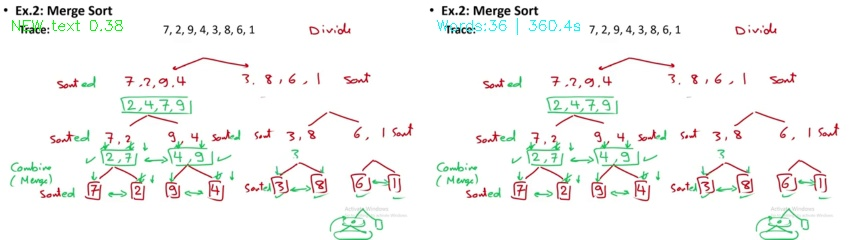

INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
📌 Saved slide 1
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
🔄 Replaced slide 1
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
🔄 Replaced slide 1
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
IN

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK


adapter_config.json: 0.00B [00:00, ?B/s]

INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK


...

✅ Transcription complete
🗑️  Freeing Whisper from GPU…
✅ Whisper freed — free VRAM: 11.8 GiB

🔄 Restoring base Qwen to GPU…
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
✅ Base Qwen restored to GPU

Total chunks created: 1



Analyzing topics:   0%|          | 0/1 [00:00<?, ?it/s]

INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK


Analyzing topics: 100%|██████████| 1/1 [00:15<00:00, 15.80s/it]


✅ Topics saved to /kaggle/working/chatbot_data/topics_with_segments.json
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK


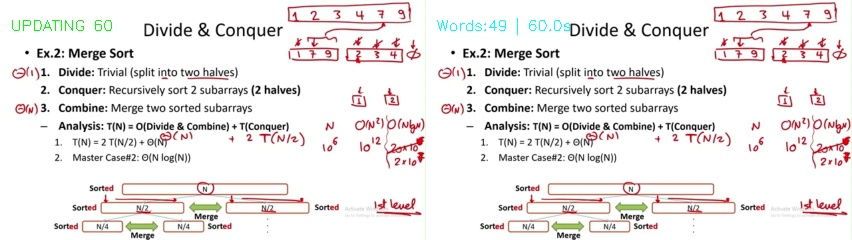

INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
📌 Saved slide 1
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
🔄 Replaced slide 1
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
🔄 Replaced slide 1
IN

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
✅ Arabic LoRA ready (on CPU)

🔄 Restoring base Qwen to GPU…
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
✅ Base Qwen restored to GPU

🔄 Offloading base Qwen to CPU…
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
✅ Base Qwen on CPU, VRAM freed

🔄 Moving Arabic model → GPU…
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK


Analyzing topics:  50%|█████     | 1/2 [01:36<01:36, 96.35s/it]

INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK


Analyzing topics: 100%|██████████| 2/2 [03:20<00:00, 100.23s/it]


✅ Topics saved to /kaggle/working/chatbot_data/topics_with_segments.json
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK


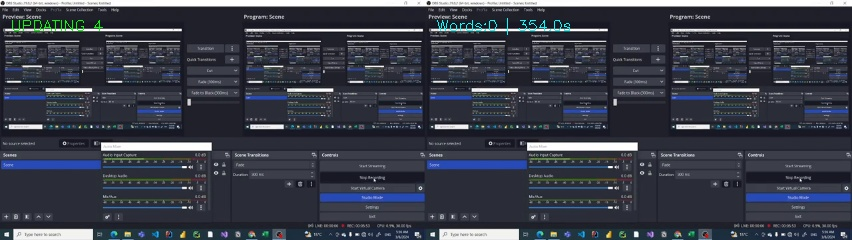

📌 Saved slide 1
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
📌 Saved slide 2
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
📌 Saved slide 3
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
📌 Saved slide 4
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
📌 Saved slide 5
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
🔄 Replaced slide 5
🔄 Replaced slide 5
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
📌 Saved slide 6
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
📌 Saved slide 7
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
📌 Saved slide 8
INFO:   

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
✅ Arabic LoRA ready (on CPU)

🔄 Restoring base Qwen to GPU…
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
✅ Base Qwen restored to GPU

🔄 Offloading base Qwen to CPU…
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
✅ Base Qwen on CPU, VRAM freed

🔄 Moving Arabic model → GPU…
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
✅ [Flashcards] Embedding model ready
   📊 2 topics → 2 after clustering

📊 [Flashcards] Scoring topics by informativeness…
   ✅ 'Classification vs Regression in Machine ' → 0.416
   ✅ 'Logistic Regression Output and Sigmoid F' → 0.475

   📊 2/2 topics passed

✂️  Pruning segments to topic context…

   ✂️ 'Logistic Regression Output and Sigmoid F' → 21 → 13 sentences (removed 8, avg_score=0.47)
   ✂️ 'Classification vs Regression in Machine ' → 16 → 10 sentences (removed 6, avg_score=0.38)

   📊 Total sentences pruned: 14

⏳ Generating flashcards…

🔄 [1/2] 'Logistic Regression Output and Sigmoid Function'
   📈 Score: 0.475 | Merged: 1 | Pruned: 306 words
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
INFO:     197.52.101.180:0 - "GET /status HTTP/1.1" 200 OK
   📖 Glossary extracted:
      - **output**: Final output of the logistic regression model. | - **sigm

In [ ]:
import nest_asyncio
import uvicorn
import threading
import time
from pyngrok import ngrok

nest_asyncio.apply()

NGROK_AUTH_TOKEN = "your token"   # <── replace
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

def _run():
    uvicorn.run(app, host="0.0.0.0", port=8000, log_level="info")

threading.Thread(target=_run, daemon=True).start()
time.sleep(2)

public_url = ngrok.connect(8000, "http")
print("=" * 55)
print(f"  🌐  URL    : {public_url}")
print(f"  📤  Upload : POST {public_url}/upload_video")
print(f"  📊  Status : GET  {public_url}/status")
print(f"  💬  Chat   : POST {public_url}/chat")
print("=" * 55)